# NWM 3.0 Peak Streamflow Performance Evaluation
### Consolidated Analysis Notebook — Oklahoma USGS Gauge Network
Evaluates NWM 3.0 simulated instantaneous peak streamflow against USGS observed data  
for **regulated** and **unregulated** stream classifications.  
Outputs site-level metrics, overall aggregated metrics, spatial maps, and sensitivity analysis.


In [280]:
import os, glob, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.lines import Line2D
from scipy import stats
from scipy.stats import mannwhitneyu
warnings.filterwarnings('ignore')

# ── reproducible figure style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})
print("Libraries loaded.")


Libraries loaded.


## ⚙️ User Configuration
*All user-adjustable parameters are in this cell only.*

In [281]:
# ═══════════════════════════════════════════════════════════════════════════════
#  USER CONFIGURATION  — edit only this cell
# ═══════════════════════════════════════════════════════════════════════════════

# ── Input data paths ──────────────────────────────────────────────────────────
REG_DIR   = r'Outputs\\Classification\\Regulated\\'       # regulated sites folder
UNREG_DIR = r'Outputs\\Classification\\Unregulated\\'     # unregulated sites folder
META_FILE = r'Outputs\\site_meta'                             # site metadata (CSV or folder)
SHP_FILE  = r'Outputs\\GIS_FIles\\oklahoma_basin_boundary.shp'
FLOWLINES_FILE = r'Outputs\\GIS_Files\\oklahoma_flowlines.shp'

# ── Output paths ──────────────────────────────────────────────────────────────
OUT_ROOT     = r'Final_Outputs'
OUT_OVERALL  = os.path.join(OUT_ROOT, 'Overall Analysis')
OUT_REG      = os.path.join(OUT_ROOT, 'Regulated')
OUT_UNREG    = os.path.join(OUT_ROOT, 'Unregulated')

# Analysis period (NWM availability)
ANALYSIS_START = pd.Timestamp("2000-01-01")
ANALYSIS_END   = pd.Timestamp("2022-12-31")

# ── Threshold method ─────────────────────────────────────────────────────────
# Choose ONE: 'return_period'  or  'percentile'
THRESHOLD_METHOD = 'return_period'

# Return-period threshold settings (used when THRESHOLD_METHOD = 'return_period')
RETURN_PERIOD_YRS = 1           

# Percentile threshold settings (used when THRESHOLD_METHOD = 'percentile')
PERCENTILE_VALUE  = 50          # e.g. 50 = median of annual peaks

# ── Peak-matching window ──────────────────────────────────────────────────────
# Default window for the main analysis (days); also used in sensitivity run
DEFAULT_WINDOW_DAYS = 7

# ── Sensitivity analysis windows (days) ──────────────────────────────────────
SENSITIVITY_WINDOWS = [3, 5, 7, 10]

# ── Drainage-area split for large vs small basins ─────────────────────────────
DA_THRESHOLD_SQKM = 1000                        # user-facing threshold in sq km
DA_THRESHOLD_SQMI = 366.102 # = 386.1 sq mi (auto-converted

# ── Performance thresholds (for bar-chart of % sites meeting criteria) ────────
KGE_THRESHOLD   =  0.5
NSE_THRESHOLD   =  0.5
PBIAS_THRESHOLD = 25.0          # |PBIAS| < this value

# ═══════════════════════════════════════════════════════════════════════════════
print("Configuration loaded.")
print(f"  Threshold method : {THRESHOLD_METHOD}")
print(f"  Default window   : {DEFAULT_WINDOW_DAYS} days")
print(f"  DA split         : {DA_THRESHOLD_SQMI} sq mi")


Configuration loaded.
  Threshold method : return_period
  Default window   : 7 days
  DA split         : 366.102 sq mi


## 📁 Create Output Directories

In [282]:
for d in [OUT_OVERALL, OUT_REG, OUT_UNREG]:
    os.makedirs(d, exist_ok=True)
    print(f"  Ready: {d}")


  Ready: Final_Outputs\Overall Analysis
  Ready: Final_Outputs\Regulated
  Ready: Final_Outputs\Unregulated


## 🔧 Helper Functions

In [283]:
# ── Metric calculations ───────────────────────────────────────────────────────
def kge(obs, sim):
    """Kling-Gupta Efficiency (Gupta et al. 2009)."""
    obs, sim = np.asarray(obs, float), np.asarray(sim, float)
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs, sim = obs[mask], sim[mask]
    if len(obs) < 2 or obs.std() == 0:
        return np.nan
    r = np.corrcoef(obs, sim)[0, 1]
    alpha = sim.std() / obs.std()
    beta  = sim.mean() / obs.mean()
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def nse(obs, sim):
    """Nash–Sutcliffe Efficiency."""
    obs, sim = np.asarray(obs, float), np.asarray(sim, float)
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs, sim = obs[mask], sim[mask]
    if len(obs) < 2 or obs.var() == 0:
        return np.nan
    return 1 - np.sum((obs - sim)**2) / np.sum((obs - obs.mean())**2)

def pbias(obs, sim):
    """Percent Bias (%)."""
    obs, sim = np.asarray(obs, float), np.asarray(sim, float)
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs, sim = obs[mask], sim[mask]
    if obs.sum() == 0:
        return np.nan
    return 100 * (obs - sim).sum() / obs.sum()

def rmse(obs, sim):
    """Root Mean Square Error."""
    obs, sim = np.asarray(obs, float), np.asarray(sim, float)
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs, sim = obs[mask], sim[mask]
    if len(obs) == 0:
        return np.nan
    return np.sqrt(np.mean((obs - sim)**2))

# ── Return-period threshold from annual maxima (Weibull plotting position) ────
def compute_return_period_threshold(annual_peaks, rp_years=2):
    """Return flow magnitude for a given return period via Weibull."""
    peaks = np.sort(annual_peaks[np.isfinite(annual_peaks)])
    if len(peaks) == 0:
        return np.nan
    n = len(peaks)
    T = (n + 1) / np.arange(1, n + 1)   # Weibull (ranks ascending → T descending)
    T = T[::-1]                           # align: smallest peak → smallest T
    if rp_years <= T.min():
        return float(peaks[0])
    if rp_years >= T.max():
        return float(peaks[-1])
    return float(np.interp(rp_years, T, peaks))

# ── Percentile threshold ──────────────────────────────────────────────────────
def compute_percentile_threshold(annual_peaks, pct=50):
    peaks = annual_peaks[np.isfinite(annual_peaks)]
    if len(peaks) == 0:
        return np.nan
    return float(np.percentile(peaks, pct))

print("Helper functions defined.")


Helper functions defined.


## 📂 Data Loading

In [284]:
# ── Column name constants (update these if your CSVs differ) ─────────────────
USGS_Q_COL = 'streamflow_m3s'   # <-- set to your actual USGS flow column name
NWM_Q_COL  = 'streamflow'  # <-- set to your actual NWM  flow column name

def load_usgs_site(site, folder):
    path = os.path.join(folder, f"{site}_USGS_inst.csv")
    df   = pd.read_csv(path, dtype={'datetime': 'string'})
    dt   = pd.to_datetime(df['datetime'], utc=True, errors='coerce', cache=True)
    df['datetime'] = dt.dt.tz_convert(None)
    df   = df.set_index('datetime').sort_index()
    series = df[USGS_Q_COL]
    # Resample 15-min → 1-hour mean to match NWM resolution
    series = series.resample('1h').mean()
    return series

def load_nwm_site(site, folder):
    path = os.path.join(folder, f"{site}_NWM_inst.csv")
    df   = pd.read_csv(path)
    df['time'] = pd.to_datetime(
        df['time'], format='%Y-%m-%d %H:%M:%S', errors='coerce'
    )
    df   = df.rename(columns={'time': 'datetime'})
    df   = df.set_index('datetime').sort_index()
    return df[NWM_Q_COL]

def load_site_pair(site_id, folder):
    """Load NWM and USGS series for a single site, return as (nwm_df, usgs_df)."""
    try:
        usgs_series = load_usgs_site(site_id, folder)
        nwm_series  = load_nwm_site(site_id,  folder)
    except FileNotFoundError as e:
        print(f"  SKIP {site_id}: {e}")
        return None, None
    except KeyError as e:
        print(f"  SKIP {site_id}: column not found — {e}")
        print(f"    Check USGS_Q_COL='{USGS_Q_COL}' and NWM_Q_COL='{NWM_Q_COL}'")
        return None, None

    # Wrap as DataFrames with standardised column names
    nwm  = nwm_series.rename('streamflow').to_frame()
    usgs = usgs_series.rename('streamflow_m3s').to_frame()

    # Safety: ensure both indices are tz-naive
    if nwm.index.tz  is not None: nwm.index  = nwm.index.tz_localize(None)
    if usgs.index.tz is not None: usgs.index = usgs.index.tz_localize(None)

    return nwm, usgs

def discover_sites(folder):
    """Return sorted list of site IDs found in a folder (NWM files)."""
    files = glob.glob(os.path.join(folder, '*_NWM_inst.csv'))
    if not files:
        files = glob.glob(os.path.join(folder, '*_NWM*'))
    return sorted(set(os.path.basename(f).split('_')[0] for f in files))

print("Data loading functions defined.")
print(f"  USGS flow column : '{USGS_Q_COL}'")
print(f"  NWM  flow column : '{NWM_Q_COL}'")

Data loading functions defined.
  USGS flow column : 'streamflow_m3s'
  NWM  flow column : 'streamflow'


## 📋 Load Site Metadata

In [285]:
# Load site metadata (accepts CSV or first CSV in a folder)
if os.path.isdir(META_FILE):
    meta_files = glob.glob(os.path.join(META_FILE, '*.csv'))
    meta_df = pd.read_csv(meta_files[0]) if meta_files else pd.DataFrame()
elif os.path.isfile(META_FILE):
    meta_df = pd.read_csv(META_FILE)
elif os.path.isfile(META_FILE + '.csv'):
    meta_df = pd.read_csv(META_FILE + '.csv')
else:
    meta_df = pd.DataFrame()
    print("WARNING: site_meta not found — spatial figures will be limited.")

if not meta_df.empty:
    # Normalise site_no column
    id_col = next((c for c in meta_df.columns
                   if 'site' in c.lower() and 'no' in c.lower()), None)
    if id_col is None:
        id_col = meta_df.columns[0]
    meta_df = meta_df.rename(columns={id_col: 'site_no'})
    meta_df['site_no'] = meta_df['site_no'].astype(str).str.zfill(8)
    print(f"Metadata loaded: {len(meta_df)} sites, columns: {list(meta_df.columns)}")
else:
    print("Metadata not loaded.")


Metadata loaded: 101 sites, columns: ['index', 'agency_cd', 'site_no', 'station_nm', 'site_tp_cd', 'lat_va', 'long_va', 'dec_lat_va', 'dec_long_va', 'coord_meth_cd', 'coord_acy_cd', 'coord_datum_cd', 'dec_coord_datum_cd', 'district_cd', 'state_cd', 'county_cd', 'country_cd', 'land_net_ds', 'map_nm', 'map_scale_fc', 'alt_va', 'alt_meth_cd', 'alt_acy_va', 'alt_datum_cd', 'huc_cd', 'basin_cd', 'topo_cd', 'instruments_cd', 'construction_dt', 'inventory_dt', 'drain_area_va', 'contrib_drain_area_va', 'tz_cd', 'local_time_fg', 'reliability_cd', 'gw_file_cd', 'nat_aqfr_cd', 'aqfr_cd', 'aqfr_type_cd', 'well_depth_va', 'hole_depth_va', 'depth_src_cd', 'project_no', 'geometry', 'final_status']


## 🔬 Peak Extraction & Per-Event Metric Computation

In [286]:
def extract_annual_peaks_and_match_nwm(nwm, usgs, window_days=DEFAULT_WINDOW_DAYS):
    """
    For each calendar year, restricted to ANALYSIS_START–ANALYSIS_END:
      1. Identify annual peak in USGS observed.
      2. Search ±window_days in NWM for matching simulated peak.
      3. Return DataFrame of matched pairs.
    """

    records = []

    # Drop NaNs and ensure tz-naive
    usgs_q = usgs["streamflow_m3s"].dropna()
    nwm_q  = nwm["streamflow"].dropna()

    if usgs_q.index.tz is not None:
        usgs_q.index = usgs_q.index.tz_localize(None)
    if nwm_q.index.tz is not None:
        nwm_q.index = nwm_q.index.tz_localize(None)

    # Restrict both series to the analysis period
    usgs_q = usgs_q.loc[ANALYSIS_START:ANALYSIS_END]
    nwm_q  = nwm_q.loc[ANALYSIS_START:ANALYSIS_END]

    if usgs_q.empty:
        return pd.DataFrame()

    window = pd.Timedelta(days=window_days)

    for yr, grp in usgs_q.groupby(usgs_q.index.year):
        if grp.empty:
            continue

        obs_peak_time = grp.idxmax()
        obs_peak_val  = grp.max()

        t0, t1 = obs_peak_time - window, obs_peak_time + window
        nwm_win = nwm_q.loc[t0:t1]

        sim_peak_val = np.nan if nwm_win.empty else nwm_win.max()

        records.append(
            {
                "year":      yr,
                "obs_peak":  obs_peak_val,
                "sim_peak":  sim_peak_val,
                "peak_time": obs_peak_time,
            }
        )

    return pd.DataFrame(records)

def compute_site_threshold(pairs_df, method=THRESHOLD_METHOD,
                           rp_years=RETURN_PERIOD_YRS,
                           pct=PERCENTILE_VALUE):
    """Compute flow threshold from annual USGS peaks."""
    annual_peaks = pairs_df['obs_peak'].values
    if method == 'return_period':
        return compute_return_period_threshold(annual_peaks, rp_years)
    else:
        return compute_percentile_threshold(annual_peaks, pct)

def compute_site_metrics(pairs_df, threshold):
    """
    Compute event-level metrics for a site using ONLY:
      - events within ANALYSIS_START–ANALYSIS_END
      - events with obs_peak >= threshold.
    """

    if pairs_df.empty:
        return {
            "KGE":   np.nan,
            "NSE":   np.nan,
            "PBIAS": np.nan,
            "RMSE":  np.nan,
            "nevents": 0,
        }, pd.Series({"KGE": np.nan, "NSE": np.nan, "PBIAS": np.nan, "RMSE": np.nan})

    df = pairs_df.copy()

    # Enforce analysis period explicitly on peak_time
    df = df[(df["peak_time"] >= ANALYSIS_START) & (df["peak_time"] <= ANALYSIS_END)]

    # Drop NaNs and apply threshold
    df = df.dropna(subset=["obs_peak", "sim_peak"])
    df = df[df["obs_peak"] >= threshold]

    n = len(df)
    if n < 2:
        metrics_site = {
            "KGE":   np.nan,
            "NSE":   np.nan,
            "PBIAS": np.nan,
            "RMSE":  np.nan,
            "nevents": n,
        }
        metrics_events = pd.Series(
            {"KGE": np.nan, "NSE": np.nan, "PBIAS": np.nan, "RMSE": np.nan}
        )
        return metrics_site, metrics_events

    obs = df["obs_peak"].values
    sim = df["sim_peak"].values

    kge_val   = kge(obs, sim)
    nse_val   = nse(obs, sim)
    pbias_val = pbias(obs, sim)
    rmse_val  = rmse(obs, sim)

    metrics_site = {
        "KGE":   kge_val,
        "NSE":   nse_val,
        "PBIAS": pbias_val,
        "RMSE":  rmse_val,
        "nevents": n,
    }
    metrics_events = pd.Series(
        {"KGE": kge_val, "NSE": nse_val, "PBIAS": pbias_val, "RMSE": rmse_val}
    )

    return metrics_site, metrics_events


## 🚀 Run Main Analysis (Default Window)

In [287]:
def run_analysis_for_class(folder, classification, window_days=DEFAULT_WINDOW_DAYS):
    """
    Run peak-extraction and performance analysis for all sites in a class.

    Parameters
    ----------
    folder : str
        Path to folder with per-site CSVs (Regulated or Unregulated).
    classification : str
        'Regulated' or 'Unregulated' (or other label).
    window_days : int
        +/- days around USGS peak for NWM matching window.

    Returns
    -------
    df_sites : pd.DataFrame
        Site-level metrics (index = site_no).
    events_df : pd.DataFrame
        Event-level records filtered to:
          - ANALYSIS_START–ANALYSIS_END
          - obs_peak >= threshold
          - non-NaN obs_peak and sim_peak
    """
    sites = discover_sites(folder)
    print(f"{classification} {len(sites)} sites found in {folder}")

    results = []
    event_records = []  # collect event-level records

    for site in sites:
        nwm, usgs = load_site_pair(site, folder)
        if nwm is None or usgs is None:
            print(f"  SKIP {site}: files not found")
            continue

        # Optional: skip sites with no NWM data in analysis period
        nwm_nonan = nwm["streamflow"].dropna()
        if nwm_nonan.loc[ANALYSIS_START:ANALYSIS_END].empty:
            print(f"  SKIP {site}: no NWM data in {ANALYSIS_START.date()}–{ANALYSIS_END.date()}")
            continue

        # Extract annual USGS peaks and matched NWM within window
        pairs = extract_annual_peaks_and_match_nwm(nwm, usgs, window_days=window_days)
        if pairs.empty:
            print(f"  SKIP {site}: no matched peaks")
            continue

        # Compute site-specific threshold from USGS peaks
        threshold = compute_site_threshold(pairs)

        # Compute metrics using ONLY analysis-period, above-threshold events
        metrics_site, metrics_events = compute_site_metrics(pairs, threshold)

        if np.isnan(metrics_site["KGE"]) or metrics_site["nevents"] < 2:
            print(f"  SKIP {site}: no events above threshold with valid metrics")
            continue

        # Store site-level metrics
        metrics_site.update(
            {
                "site_no": site,
                "classification": classification,
                "threshold_m3s": threshold,
                "nyears": len(pairs),
                "nevents": metrics_site["nevents"],
            }
        )
        results.append(metrics_site)

        # Rebuild the filtered event subset used in compute_site_metrics
        df_events = pairs.copy()
        df_events = df_events[
            (df_events["peak_time"] >= ANALYSIS_START)
            & (df_events["peak_time"] <= ANALYSIS_END)
        ]
        df_events = df_events.dropna(subset=["obs_peak", "sim_peak"])
        df_events = df_events[df_events["obs_peak"] >= threshold]

        # Tag event-level records and attach metrics
        if not df_events.empty:
            df_events["site_no"] = site
            df_events["classification"] = classification
            df_events["threshold_m3s"] = threshold
            df_events["above_threshold"] = True  # all remaining events pass threshold

            for col, val in metrics_events.items():
                df_events[col] = val

            event_records.append(df_events)

    df_sites = pd.DataFrame(results).set_index("site_no") if results else pd.DataFrame()
    events_df = pd.concat(event_records, ignore_index=True) if event_records else pd.DataFrame()

    print(f"{len(df_sites)} sites with valid metrics, {len(events_df)} total event records")
    return df_sites, events_df

In [288]:
# Run for both classes with updated API
df_reg, events_reg   = run_analysis_for_class(REG_DIR,   "Regulated",   DEFAULT_WINDOW_DAYS)
df_unreg, events_unreg = run_analysis_for_class(UNREG_DIR, "Unregulated", DEFAULT_WINDOW_DAYS)

# Combine
df_all     = pd.concat([df_reg, df_unreg])
events_all = pd.concat([events_reg, events_unreg], ignore_index=True)

print(f"Total sites:  {len(df_all)}")
print(f"Total events: {len(events_all)}")
df_all.head()

Regulated 80 sites found in Outputs\\Classification\\Regulated\\
80 sites with valid metrics, 1805 total event records
Unregulated 21 sites found in Outputs\\Classification\\Unregulated\\
21 sites with valid metrics, 469 total event records
Total sites:  101
Total events: 2274


,KGE,NSE,PBIAS,RMSE,nevents,classification,threshold_m3s,nyears
site_no,,,,,,,,
07152000,0.516029,0.343726,3.745768,352.723325,23,Regulated,77.729616,23
07153000,-0.811772,-3.130692,-16.827048,243.006043,23,Regulated,20.232354,23
07157950,0.644714,0.533063,10.080879,39.464818,22,Regulated,0.976930,22
07158000,0.417680,0.364911,47.030252,118.742075,23,Regulated,4.700589,23
07159100,0.384849,0.333863,43.392694,322.196088,23,Regulated,64.845472,23


## 🔗 Save All Raw Event-Level Data

In [289]:
# ── Export event-level raw data (already collected in run_analysis_for_class) ─
#add performace metrics at event level KGE, NSE, PBIAS, RMSE

col_order  = ['site_no', 'classification', 'year', 'peak_time',
              'obs_peak', 'sim_peak', 'threshold_m3s', 'above_threshold', 'KGE', 'NSE', 'PBIAS', 'RMSE']
events_out = events_all[[c for c in col_order if c in events_all.columns]]

events_path = os.path.join(OUT_OVERALL, 'all_events_raw.csv')
events_out.to_csv(events_path, index=False)

print(f"  Total event records : {len(events_out)}")
print(f"  Above threshold     : {events_out['above_threshold'].sum()}")
print(f"  Sites included      : {events_out['site_no'].nunique()}")
print(f"  Saved → {events_path}")
events_out.head()

  Total event records : 2274
  Above threshold     : 2274
  Sites included      : 101
  Saved → Final_Outputs\Overall Analysis\all_events_raw.csv


,site_no,classification,year,peak_time,obs_peak,sim_peak,threshold_m3s,above_threshold,KGE,NSE,PBIAS,RMSE
0,07152000,Regulated,2000,2000-03-25 05:00:00,1077.45424,1035.499977,77.729616,True,0.516029,0.343726,3.745768,352.723325
1,07152000,Regulated,2001,2001-02-25 10:00:00,761.72192,373.579992,77.729616,True,0.516029,0.343726,3.745768,352.723325
2,07152000,Regulated,2002,2002-10-04 21:00:00,975.51376,391.169991,77.729616,True,0.516029,0.343726,3.745768,352.723325
3,07152000,Regulated,2003,2003-03-20 11:00:00,883.48416,472.359989,77.729616,True,0.516029,0.343726,3.745768,352.723325
4,07152000,Regulated,2004,2004-03-05 23:00:00,930.20688,622.949986,77.729616,True,0.516029,0.343726,3.745768,352.723325


## 🔗 Merge with Site Metadata

In [290]:
if not meta_df.empty:
    # Drop existing metadata columns if they exist (from previous runs)
    cols_to_drop = ['lat', 'lon', 'drain_area_sqmi', 'DA_class']
    df_all = df_all.drop(columns=[c for c in cols_to_drop if c in df_all.columns])
    
    # Ensure site_no is a column in df_all for merging
    df_all = df_all.reset_index()
    
    df_all = df_all.merge(
        meta_df[['site_no', 'dec_lat_va', 'dec_long_va', 'drain_area_va']].rename(
            columns={'dec_lat_va': 'lat', 'dec_long_va': 'lon',
                     'drain_area_va': 'drain_area_sqmi'}),
        on='site_no', how='left'
    )
    
    # Now drain_area_sqmi exists, so we can use it
    df_all['DA_class'] = np.where(
        df_all['drain_area_sqmi'] >= DA_THRESHOLD_SQMI, 'Large', 'Small')
    
    # Set index back to site_no
    df_all = df_all.set_index('site_no')
    
    print(f"Metadata merged. Drainage area split: "
          f"{(df_all['DA_class']=='Large').sum()} Large, "
          f"{(df_all['DA_class']=='Small').sum()} Small")
else:
    df_all['lat'] = np.nan
    df_all['lon'] = np.nan
    df_all['drain_area_sqmi'] = np.nan
    df_all['DA_class'] = np.nan
    print("No metadata — lat/lon/drain_area set to NaN.")

# Re-split by classification
df_reg_m   = df_all[df_all['classification'] == 'Regulated']
df_unreg_m = df_all[df_all['classification'] == 'Unregulated']

# Save CSVs
df_all.reset_index().to_csv(
    os.path.join(OUT_OVERALL, 'site_metrics_all.csv'), index=False)
df_reg_m.reset_index().to_csv(
    os.path.join(OUT_REG, 'site_metrics_regulated.csv'), index=False)
df_unreg_m.reset_index().to_csv(
    os.path.join(OUT_UNREG, 'site_metrics_unregulated.csv'), index=False)
print("Site-level metric CSVs saved.")


Metadata merged. Drainage area split: 66 Large, 35 Small
Site-level metric CSVs saved.


## 📊 Overall Aggregated Metrics (Median of Site Metrics)

In [291]:
def aggregate_metrics(df, label=''):
    """Compute median of site-level metrics for a group."""
    cols = ['KGE', 'NSE', 'PBIAS', 'RMSE']
    agg = {}
    for c in cols:
        vals = df[c].dropna()
        agg[f'median_{c}'] = vals.median()
        agg[f'mean_{c}']   = vals.mean()
        agg[f'std_{c}']    = vals.std()
        agg[f'n_sites']    = len(vals)
    return agg

overall_all  = aggregate_metrics(df_all,     'All')
overall_reg  = aggregate_metrics(df_reg_m,   'Regulated')
overall_unreg= aggregate_metrics(df_unreg_m, 'Unregulated')

overall_df = pd.DataFrame([
    {'group': 'All',          **overall_all},
    {'group': 'Regulated',    **overall_reg},
    {'group': 'Unregulated',  **overall_unreg},
])
overall_df.to_csv(os.path.join(OUT_OVERALL, 'overall_metrics_summary.csv'), index=False)
print("\nOverall Aggregated Metrics (Median):")
print(overall_df[['group','median_KGE','median_NSE','median_PBIAS','median_RMSE',
                  'n_sites']].to_string(index=False))



Overall Aggregated Metrics (Median):
      group  median_KGE  median_NSE  median_PBIAS  median_RMSE  n_sites
        All    0.285035   -0.081665     10.080879   181.169583      101
  Regulated    0.242845   -0.211037      9.767597   194.250761       80
Unregulated    0.510374    0.200259     13.150493    79.598457       21


## 🔁 Sensitivity Analysis (Window Size × Drainage Area & Reg/Unreg)

In [292]:
sens_records  = []
sens_events   = []

for w in SENSITIVITY_WINDOWS:
    print(f"  Running window = {w} days …")
    for folder, cls in [(REG_DIR, 'Regulated'), (UNREG_DIR, 'Unregulated')]:
        df_w, events_w = run_analysis_for_class(folder, cls, window_days=w)
        if df_w.empty:
            continue

        # Tag event-level data with window
        events_w['window_days'] = w
        sens_events.append(events_w)

        # Merge drain_area back
        if not meta_df.empty:
            df_w = df_w.merge(
                meta_df[['site_no', 'drain_area_va']].rename(
                    columns={'drain_area_va': 'drain_area_sqmi'}),
                left_index=True, right_on='site_no', how='left'
            ).set_index('site_no')
            df_w['DA_class'] = np.where(
                df_w['drain_area_sqmi'] >= DA_THRESHOLD_SQMI, 'Large', 'Small')

        # ── Store site-level values for ALL 4 metrics per window ──────────
        rec = {
            'window_days':    w,
            'classification': cls,
            'DA_class':       'All',
            'n_sites':        len(df_w),
            'median_KGE':     df_w['KGE'].median(),
            'median_NSE':     df_w['NSE'].median(),
            'median_PBIAS':   df_w['PBIAS'].median(),
            'median_RMSE':    df_w['RMSE'].median(),
        }
        sens_records.append(rec)

        # Also keep DA-class breakdown if needed elsewhere
        if 'DA_class' in df_w.columns:
            for da_cls in ['Large', 'Small']:
                sub = df_w[df_w['DA_class'] == da_cls]
                if sub.empty:
                    continue
                sens_records.append({
                    'window_days':    w,
                    'classification': cls,
                    'DA_class':       da_cls,
                    'n_sites':        len(sub),
                    'median_KGE':     sub['KGE'].median(),
                    'median_NSE':     sub['NSE'].median(),
                    'median_PBIAS':   sub['PBIAS'].median(),
                    'median_RMSE':    sub['RMSE'].median(),
                })

# Save aggregated sensitivity metrics
sens_df = pd.DataFrame(sens_records)
sens_df.to_csv(os.path.join(OUT_OVERALL, 'sensitivity_analysis.csv'), index=False)

# Save combined raw event-level data for all windows
sens_events_df = pd.concat(sens_events, ignore_index=True)
col_order = ['window_days', 'site_no', 'classification', 'year', 'peak_time',
             'obs_peak', 'sim_peak', 'threshold_m3s', 'above_threshold']
sens_events_df = sens_events_df[[c for c in col_order if c in sens_events_df.columns]]
sens_events_path = os.path.join(OUT_OVERALL, 'sensitivity_all_events_raw.csv')
sens_events_df.to_csv(sens_events_path, index=False)

print("\nSensitivity analysis complete.")
print(f"  Windows run     : {SENSITIVITY_WINDOWS}")
print(f"  Aggregated rows : {len(sens_df)}")
print(f"  Raw event rows  : {len(sens_events_df)}")
print(sens_df[sens_df['DA_class']=='All'].to_string(index=False))

  Running window = 3 days …
Regulated 80 sites found in Outputs\\Classification\\Regulated\\
80 sites with valid metrics, 1805 total event records
Unregulated 21 sites found in Outputs\\Classification\\Unregulated\\
21 sites with valid metrics, 469 total event records
  Running window = 5 days …
Regulated 80 sites found in Outputs\\Classification\\Regulated\\
80 sites with valid metrics, 1805 total event records
Unregulated 21 sites found in Outputs\\Classification\\Unregulated\\
21 sites with valid metrics, 469 total event records
  Running window = 7 days …
Regulated 80 sites found in Outputs\\Classification\\Regulated\\
80 sites with valid metrics, 1805 total event records
Unregulated 21 sites found in Outputs\\Classification\\Unregulated\\
21 sites with valid metrics, 469 total event records
  Running window = 10 days …
Regulated 80 sites found in Outputs\\Classification\\Regulated\\
80 sites with valid metrics, 1805 total event records
Unregulated 21 sites found in Outputs\\Classi

## 🗺️ Load Oklahoma Shapefile

In [293]:
try:
    ok_shp = gpd.read_file(SHP_FILE).to_crs(epsg=4326)
    print(f"Shapefile loaded: {len(ok_shp)} features, CRS: {ok_shp.crs}")
    HAS_SHP = True
except Exception as e:
    print(f"Could not load shapefile: {e}")
    ok_shp = None
    HAS_SHP = False

# Build GeoDataFrame for sites
valid_geo = df_all.dropna(subset=['lat','lon'])
if len(valid_geo):
    sites_gdf = gpd.GeoDataFrame(
        valid_geo.copy(),
        geometry=gpd.points_from_xy(valid_geo['lon'], valid_geo['lat']),
        crs='EPSG:4326'
    )
    HAS_GEO = True
    print(f"Site GeoDataFrame: {len(sites_gdf)} sites with coordinates")
else:
    sites_gdf = None
    HAS_GEO = False
    print("WARNING: No site coordinates available — map figures will be skipped.")


Shapefile loaded: 1 features, CRS: EPSG:4326
Site GeoDataFrame: 101 sites with coordinates


## 🎨 Figure Utilities

In [294]:
REG_COLOR   = '#1f78b4'   # blue
UNREG_COLOR = '#e31a1c'   # red
COLORS = {'Regulated': REG_COLOR, 'Unregulated': UNREG_COLOR}

def save_fig(fig, path, tight=True):
    if tight:
        fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches='tight', format='png')
    plt.show()        # ← display inline in notebook BEFORE closing
    plt.close(fig)
    print(f"  Saved → {path}")

def strip_outliers_for_plot(series, iqr_mult=3):
    """Cap extreme outliers for axis range only (not data removal)."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - iqr_mult*iqr, q3 + iqr_mult*iqr
    return lo, hi

print("Figure utilities defined.")

def annotate_medians(ax, data_list, positions=None):
    """Write median value above each box in a boxplot."""
    if positions is None:
        positions = range(1, len(data_list) + 1)
    for pos, data in zip(positions, data_list):
        med = np.nanmedian(data)
        ax.text(pos, med, f'{med:.2f}',
                ha='center', va='bottom',
                fontsize=8, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.15', fc='white',
                          ec='none', alpha=0.7))
        
metrics_list = ['KGE', 'NSE', 'PBIAS', 'RMSE']

Figure utilities defined.


## 🗺️ Overall Figure 1 — Spatial Map of Gauge Locations (Median KGE)

Flowlines plotted.


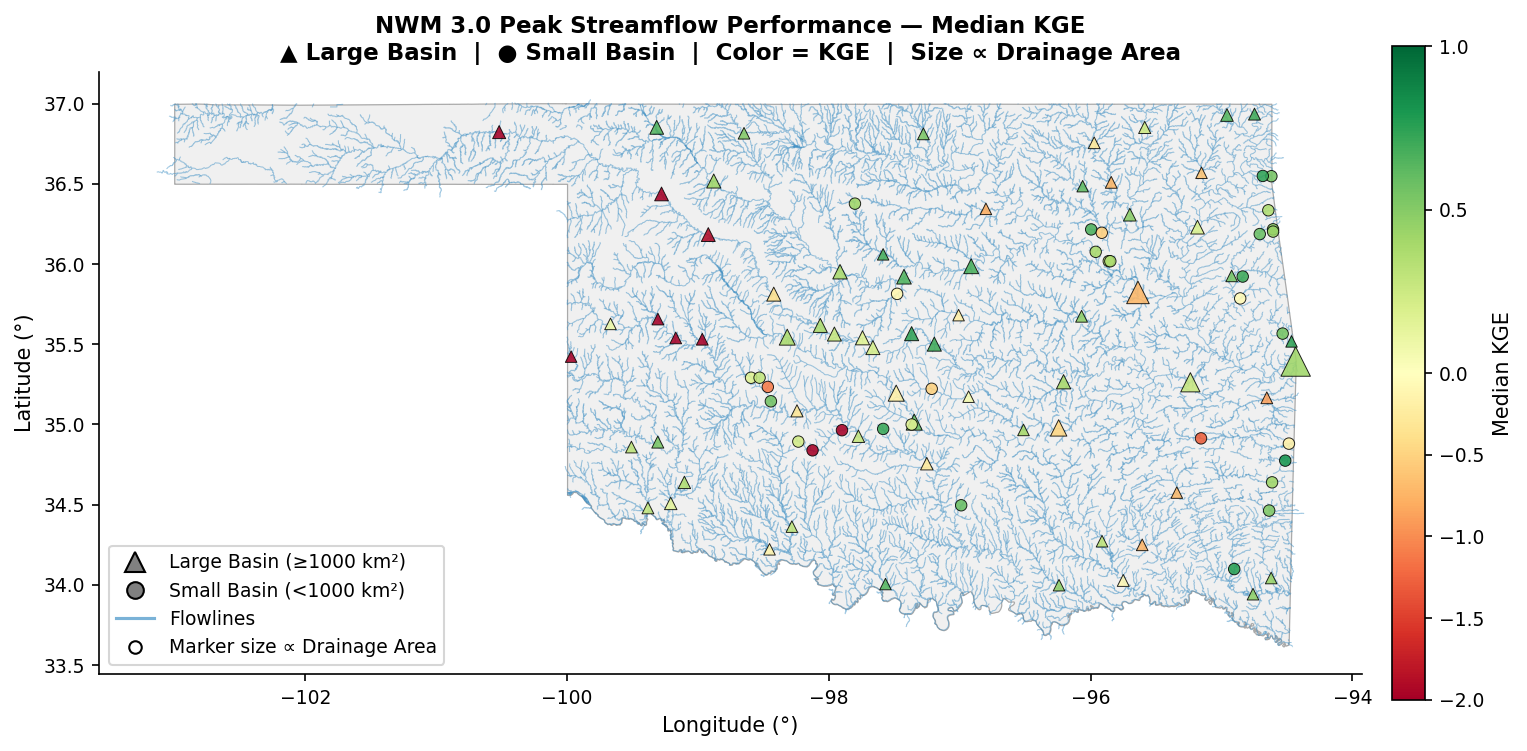

  Saved → Final_Outputs\Overall Analysis\Fig01_Map_KGE_BasinSize.png


In [295]:
if HAS_GEO:
    fig, ax = plt.subplots(figsize=(11, 7))

    # ── Base: Oklahoma basin boundary ─────────────────────────────────────
    if HAS_SHP:
        ok_shp.plot(ax=ax, color='#f0f0f0', edgecolor='#aaaaaa', linewidth=0.6)

    # ── Flowlines ─────────────────────────────────────────────────────────
    try:
        flowlines = gpd.read_file(FLOWLINES_FILE).to_crs(epsg=4326)
        flowlines.plot(ax=ax, color='#4292c6', linewidth=0.5,
                       alpha=0.5, zorder=2)
        print("Flowlines plotted.")
    except Exception as e:
        print(f"  WARNING: Could not load flowlines — {e}")

    # ── Colormap centred at KGE=0 ─────────────────────────────────────────
    kge_vals = sites_gdf['KGE'].dropna()
    vmin = max(-2, kge_vals.min())
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=1.0)
    cmap = plt.cm.RdYlGn

    # ── Scale marker size by drainage area ────────────────────────────────
    # Define size range: min and max marker sizes
    MIN_SIZE = 30   # smallest basin marker size
    MAX_SIZE = 200  # largest basin marker size
    
    # Get drainage area values (assuming column name is 'drainage_area_sqkm' or similar)
    # Replace 'drainage_area_sqkm' with your actual column name
    da_col = 'drain_area_sqmi'  # adjust to your actual column name
    
    # Scale sizes proportionally to drainage area (using sqrt for better visual scaling)
    da_values = sites_gdf[da_col].dropna()
    size_scale = (sites_gdf[da_col] - da_values.min()) / (da_values.max() - da_values.min())
    marker_sizes = MIN_SIZE + size_scale * (MAX_SIZE - MIN_SIZE)

    # ── Plot: marker shape = basin class, size = drainage area ────────────
    da_marker_map = {'Large': '^', 'Small': 'o'}

    for da_cls, marker in da_marker_map.items():
        sub = sites_gdf[sites_gdf['DA_class'] == da_cls].dropna(subset=['KGE'])
        if sub.empty:
            continue
        
        # Get sizes for this subset
        sub_sizes = marker_sizes.loc[sub.index]
        
        sc = ax.scatter(
            sub.geometry.x, sub.geometry.y,
            c=sub['KGE'], cmap=cmap, norm=norm,
            s=sub_sizes,  # ← SIZE NOW VARIES BY DRAINAGE AREA
            marker=marker,
            edgecolors='k', linewidths=0.45, alpha=0.88,
            zorder=3,
            label=f'{da_cls} Basin ({"≥" if da_cls == "Large" else "<"}{DA_THRESHOLD_SQKM} km²)'
        )

    # ── Colorbar ──────────────────────────────────────────────────────────
    plt.colorbar(
        cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax,
        shrink=0.65, pad=0.02, label='Median KGE'
    )

    # ── Legend with size reference ────────────────────────────────────────
    # Show 3 example drainage areas for size reference
    da_examples = np.percentile(sites_gdf[da_col].dropna(), [10, 50, 90])
    size_examples = MIN_SIZE + (da_examples - da_values.min()) / (da_values.max() - da_values.min()) * (MAX_SIZE - MIN_SIZE)
    
    handles = [
        Line2D([0],[0], marker='^', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=10,
               label=f'Large Basin (≥{DA_THRESHOLD_SQKM} km²)'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=8,
               label=f'Small Basin (<{DA_THRESHOLD_SQKM} km²)'),
        Line2D([0],[0], color='#4292c6', linewidth=1.5,
               alpha=0.7, label='Flowlines'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='none',
               markeredgecolor='k', markersize=6,
               label=f'Marker size ∝ Drainage Area'),
    ]
    ax.legend(handles=handles, loc='lower left', framealpha=0.8)
    ax.set_xlabel('Longitude (°)')
    ax.set_ylabel('Latitude (°)')
    ax.set_title('NWM 3.0 Peak Streamflow Performance — Median KGE\n'
                 '▲ Large Basin  |  ● Small Basin  |  Color = KGE  |  Size ∝ Drainage Area',
                 fontweight='bold')
    save_fig(fig, os.path.join(OUT_OVERALL, 'Fig01_Map_KGE_BasinSize.png'))
else:
    print("Skipping map — no coordinates available.")


Flowlines plotted.


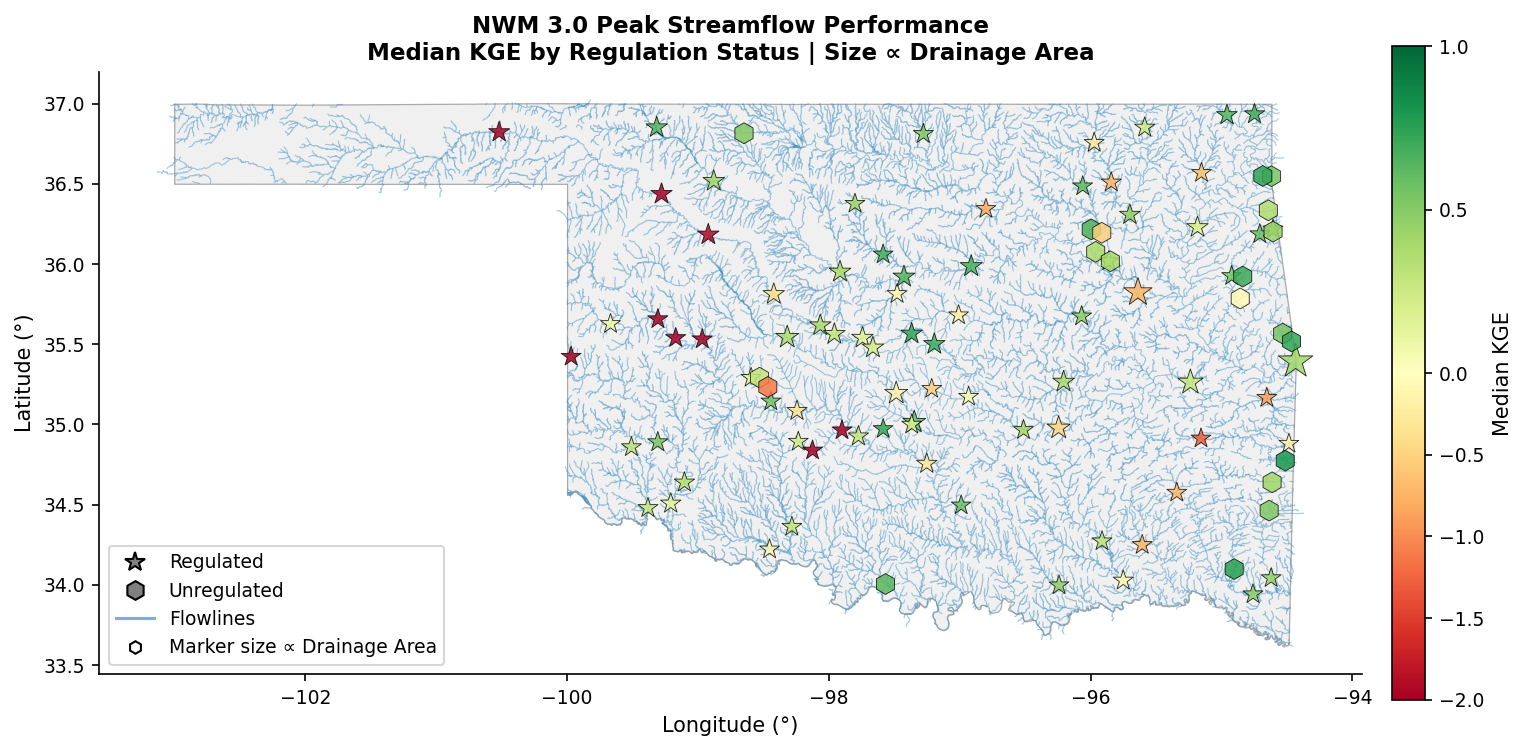

  Saved → Final_Outputs\Overall Analysis\Fig01b_Map_KGE_Gauges.png


In [296]:
if HAS_GEO:
    fig, ax = plt.subplots(figsize=(11, 7))

    # ── Base: Oklahoma basin boundary ─────────────────────────────────────
    if HAS_SHP:
        ok_shp.plot(ax=ax, color='#f0f0f0', edgecolor='#aaaaaa', linewidth=0.6)

    # ── Flowlines ─────────────────────────────────────────────────────────
    try:
        flowlines = gpd.read_file(FLOWLINES_FILE).to_crs(epsg=4326)
        flowlines.plot(
            ax=ax,
            color='#4292c6',
            linewidth=0.5,
            alpha=0.5,
            zorder=2
        )
        print("Flowlines plotted.")
    except Exception as e:
        print(f"  WARNING: Could not load flowlines — {e}")

    # ── Diverging colormap centred at KGE = 0 ─────────────────────────────
    kge_vals = sites_gdf['KGE'].dropna()
    vmin, vmax = max(-2, kge_vals.min()), 1.0
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    cmap = plt.cm.RdYlGn

    # ── Scale marker size by drainage area ────────────────────────────────
    MIN_SIZE = 100
    MAX_SIZE = 300

    da_col = 'drain_area_sqmi'

    da_values = sites_gdf[da_col].dropna()
    size_scale = (sites_gdf[da_col] - da_values.min()) / (da_values.max() - da_values.min() + 1e-9)
    marker_sizes = MIN_SIZE + size_scale * (MAX_SIZE - MIN_SIZE)

    # ── Plot gauges: shape = regulation class, size = drainage area ───────
    for cls, marker in [('Regulated', '*'), ('Unregulated', 'h')]:
        sub = sites_gdf[sites_gdf['classification'] == cls].dropna(subset=['KGE'])
        if sub.empty:
            continue

        # Get sizes for this subset
        sub_sizes = marker_sizes.loc[sub.index]

        ax.scatter(
            sub.geometry.x, sub.geometry.y,
            c=sub['KGE'], cmap=cmap, norm=norm,
            s=sub_sizes,  # ← SIZE NOW VARIES BY DRAINAGE AREA
            marker=marker,
            edgecolors='k', linewidths=0.4, alpha=0.85,
            zorder=3
        )

    cbar = plt.colorbar(
        cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax,
        shrink=0.65, pad=0.02, label='Median KGE'
    )

    # ── Legend: marker shape + flowline + size note ───────────────────────
    handles = [
        Line2D([0], [0], marker='*', color='w',
               markerfacecolor='gray', markeredgecolor='k',
               markersize=10, label='Regulated'),
        Line2D([0], [0], marker='h', color='w',
               markerfacecolor='gray', markeredgecolor='k',
               markersize=9, label='Unregulated'),
        Line2D([0], [0], color='#4292c6', linewidth=1.5,
               alpha=0.7, label='Flowlines'),
        Line2D([0], [0], marker='h', color='w', markerfacecolor='none',
               markeredgecolor='k', markersize=6,
               label='Marker size ∝ Drainage Area'),
    ]
    ax.legend(handles=handles, loc='lower left', framealpha=0.8)

    ax.set_xlabel('Longitude (°)')
    ax.set_ylabel('Latitude (°)')
    ax.set_title('NWM 3.0 Peak Streamflow Performance\n'
                 'Median KGE by Regulation Status | Size ∝ Drainage Area',
                 fontweight='bold')

    save_fig(fig, os.path.join(OUT_OVERALL, 'Fig01b_Map_KGE_Gauges.png'))
else:
    print("Skipping map — no coordinates available.")


In [297]:
# # ── Figure XX: 4 Best & 4 Worst Peak Windows by KGE ─────────────────────────
# import matplotlib.dates as mdates

# # ── 1. Reset index so siteno is a plain column, then rank ────────────────────
# mc = events_all.reset_index()          # ← this is the fix
# mc = mc.dropna(subset=['KGE']).copy()
# mc_sorted = mc.sort_values('KGE', ascending=False)

# best4  = mc_sorted.head(4).copy()
# worst4 = mc_sorted.tail(4).copy()

# print("Best 4 by KGE:")
# display(best4[['classification', 'site_no', 'year', 'KGE', 'NSE']])
# print("\nWorst 4 by KGE:")
# display(worst4[['classification', 'site_no', 'year', 'KGE', 'NSE']])


# # ── 2. Helper: plot one peak window panel ────────────────────────────────────
# def plot_peak_window(ax, row, windows_all):
#     cls  = row['classification']
#     site = row['site_no']
#     yr   = int(row['year'])
#     kge  = row['KGE']
#     nse  = row.get('NSE', float('nan'))

#     key = (cls, site)
#     if key not in windows_all or yr not in windows_all[key]:
#         ax.text(0.5, 0.5, f'No window\n{cls}\n{site} {yr}',
#                 ha='center', va='center', fontsize=8)
#         ax.axis('off')
#         return

#     merged, peaktime, obspeak, simpeak = windows_all[key][yr]

#     # detect column names (handles multiple naming conventions)
#     if {'USGS_m3s', 'NWM_m3s'}.issubset(merged.columns):
#         obs_col, sim_col = 'USGS_m3s', 'NWM_m3s'
#     elif {'obsq', 'simq'}.issubset(merged.columns):
#         obs_col, sim_col = 'obsq', 'simq'
#     elif {'obspeak', 'simpeak'}.issubset(merged.columns):
#         obs_col, sim_col = 'obspeak', 'simpeak'
#     else:
#         obs_col = next((c for c in merged.columns if 'usgs' in c.lower() or 'obs' in c.lower()), None)
#         sim_col = next((c for c in merged.columns if 'nwm'  in c.lower() or 'sim' in c.lower()), None)
#         if not obs_col or not sim_col:
#             ax.text(0.5, 0.5, 'Obs/Sim columns\nnot found',
#                     ha='center', va='center', fontsize=8)
#             ax.axis('off')
#             return

#     ax.plot(merged.index, merged[obs_col],
#             color='steelblue', lw=1.5, label='USGS Obs')
#     ax.plot(merged.index, merged[sim_col],
#             color='darkorange', lw=1.2, ls='--', label='NWM Sim')
#     ax.axvline(peaktime, color='grey', lw=0.8, ls=':')

#     ax.set_title(f'{cls}\n{site}  {yr}\nKGE={kge:.2f}  NSE={nse:.2f}',
#                  fontsize=8, pad=3)
#     ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
#     ax.tick_params(axis='x', labelsize=7, rotation=30)
#     ax.tick_params(axis='y', labelsize=7)
#     ax.grid(alpha=0.25)


# # ── 3. Build figure: top row = 4 best, bottom row = 4 worst ─────────────────
# fig, axes = plt.subplots(2, 4, figsize=(14, 6.5), sharey=False)

# for ax, (_, row) in zip(axes[0], best4.iterrows()):
#     plot_peak_window(ax, row, windows_all)
# axes[0][0].set_ylabel('Flow (m³/s)', fontsize=9)

# for ax, (_, row) in zip(axes[1], worst4.iterrows()):
#     plot_peak_window(ax, row, windows_all)
# axes[1][0].set_ylabel('Flow (m³/s)', fontsize=9)

# for ax in axes[1]:
#     ax.set_xlabel('Date', fontsize=8)

# axes[0][0].annotate('Best 4', xy=(-0.25, 0.5), xycoords='axes fraction',
#                     fontsize=10, fontweight='bold', rotation=90,
#                     va='center', ha='center')
# axes[1][0].annotate('Worst 4', xy=(-0.25, 0.5), xycoords='axes fraction',
#                     fontsize=10, fontweight='bold', rotation=90,
#                     va='center', ha='center')

# handles, labels = axes[0][0].get_legend_handles_labels()
# if handles:
#     fig.legend(handles, labels, loc='lower right', fontsize=8, ncol=2)

# fig.suptitle(f'4 Best & 4 Worst Peak Windows by KGE  (±{DEFAULT_WINDOW_DAYS} d)',
#              fontsize=11, y=1.01)
# fig.tight_layout()

# out_path = os.path.join(OUT_OVERALL, 'FigXX_best4_worst4_KGE_windows.png')
# fig.savefig(out_path, dpi=150, bbox_inches='tight')
# plt.show()
# print(f'Figure saved → {out_path}')

## 📈 Overall Figure 2 — Median KGE vs Drainage Area

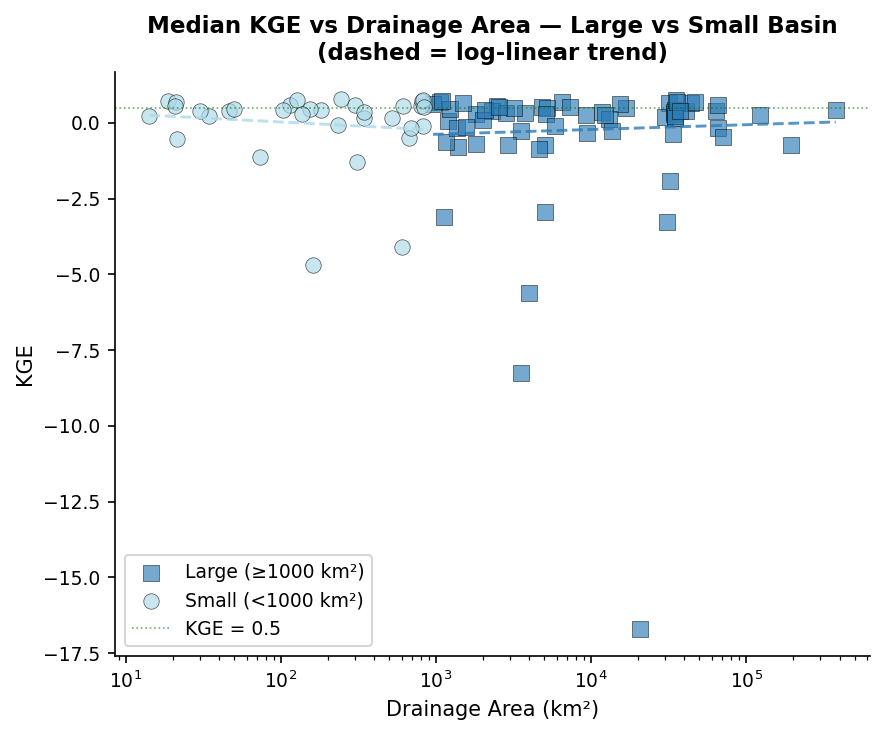

  Saved → Final_Outputs\Overall Analysis\Fig02_KGE_vs_DrainageArea.png


In [312]:
# ── Fig02 — KGE vs Drainage Area coloured by Basin Size ──────────────────────
da_col = 'drain_area_sqmi'

# Convert sq mi to sq km for plotting (1 sq mi = 2.58999 sq km)
df_all['drain_area_sqkm'] = df_all[da_col] * 2.58999
da_col_plot = 'drain_area_sqkm'

fig, ax = plt.subplots(figsize=(6, 5))

for cls in ['Large', 'Small']:
    sub = df_all[df_all['DA_class'] == cls].dropna(subset=['KGE', da_col_plot])
    if sub.empty:
        continue

    color  = '#2c7bb6' if cls == 'Large' else '#abd9e9'
    marker = 's'       if cls == 'Large' else 'o'
    label  = f'Large (≥{DA_THRESHOLD_SQKM} km²)' if cls == 'Large' \
             else f'Small (<{DA_THRESHOLD_SQKM} km²)'

    ax.scatter(sub[da_col_plot], sub['KGE'],
               color=color, alpha=0.65, s=55,
               marker=marker,
               edgecolors='k', linewidths=0.35,
               label=label)

    # log-space trend line
    log_da = np.log10(sub[da_col_plot].clip(lower=1))
    if len(log_da) > 3:
        m, b, r, p, _ = stats.linregress(log_da, sub['KGE'].clip(lower=-5))
        xs = np.linspace(log_da.min(), log_da.max(), 200)
        ax.plot(10**xs, m*xs + b,
                color=color, linewidth=1.4, linestyle='--', alpha=0.8)

ax.axhline(0.5, color='green', linewidth=0.8, linestyle=':', alpha=0.6,
           label='KGE = 0.5')
ax.set_xscale('log')
ax.set_xlabel('Drainage Area (km²)')
ax.set_ylabel('KGE')
ax.set_title('Median KGE vs Drainage Area — Large vs Small Basin\n'
             '(dashed = log-linear trend)',
             fontweight='bold')
ax.legend()

save_fig(fig, os.path.join(OUT_OVERALL, 'Fig02_KGE_vs_DrainageArea.png'))


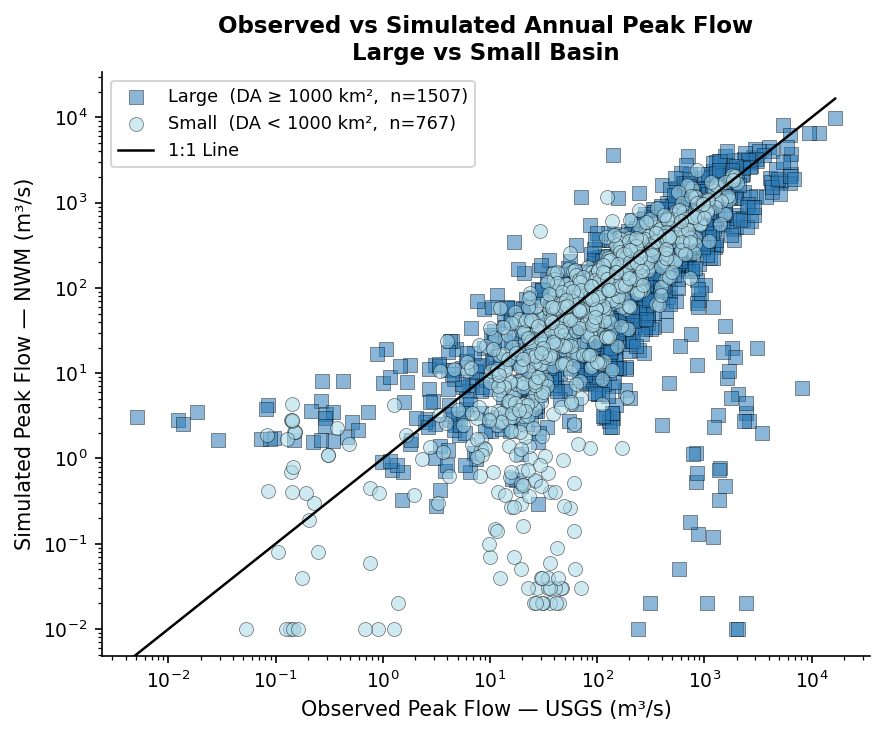

  Saved → Final_Outputs\Overall Analysis\Fig02b_ObsSim_Scatter_BasinSize.png


In [299]:
# ── Fig: Observed vs Simulated Peak Flow — Large vs Small Basin ──────────────

# ── 1. Merge D_class onto events_out (event-level) ───────────────────────────
site_meta = df_all.reset_index()[['site_no', 'drain_area_sqmi', 'DA_class']] \
                 .drop_duplicates('site_no')

events_plot = events_out.merge(site_meta, on='site_no', how='left')

# ── 2. Style maps ─────────────────────────────────────────────────────────────
colors  = {'Large': '#2c7bb6', 'Small': '#abd9e9'}
markers = {'Large': 's',       'Small': 'o'}

fig, ax = plt.subplots(figsize=(6, 5))

all_obs, all_sim = [], []

for da_cls in ['Large', 'Small']:
    sub = events_plot[events_plot['DA_class'] == da_cls].dropna(
              subset=['obs_peak', 'sim_peak'])
    if sub.empty:
        print(f'Skipping {da_cls} — no data')
        continue

    n = len(sub)
    label = (f'Large  (DA ≥ {DA_THRESHOLD_SQKM:.0f} km²,  n={n})'
             if da_cls == 'Large'
             else f'Small  (DA < {DA_THRESHOLD_SQKM:.0f} km²,  n={n})')

    ax.scatter(sub['obs_peak'], sub['sim_peak'],
               color=colors[da_cls],
               marker=markers[da_cls],
               s=45, alpha=0.55,
               edgecolors='k', linewidths=0.35,
               label=label)

    all_obs.append(sub['obs_peak'])
    all_sim.append(sub['sim_peak'])

if all_obs:
    all_obs_s = pd.concat(all_obs).dropna()
    all_sim_s = pd.concat(all_sim).dropna()
    vmin = min(all_obs_s.min(), all_sim_s.min())
    vmax = max(all_obs_s.max(), all_sim_s.max())

    # 1:1 line only
    ax.plot([vmin, vmax], [vmin, vmax],
            color='black', linewidth=1.2, linestyle='-',
            label='1:1 Line', zorder=5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Observed Peak Flow — USGS (m³/s)', fontsize=10)
ax.set_ylabel('Simulated Peak Flow — NWM (m³/s)', fontsize=10)
ax.set_title('Observed vs Simulated Annual Peak Flow\nLarge vs Small Basin',
             fontweight='bold', fontsize=11)
ax.legend(fontsize=8.5)
ax.grid(False)

save_fig(fig, os.path.join(OUT_OVERALL, 'Fig02b_ObsSim_Scatter_BasinSize.png'))

## 📦 Overall Figure 3 — Box Plots of Metrics (Reg vs Unreg)

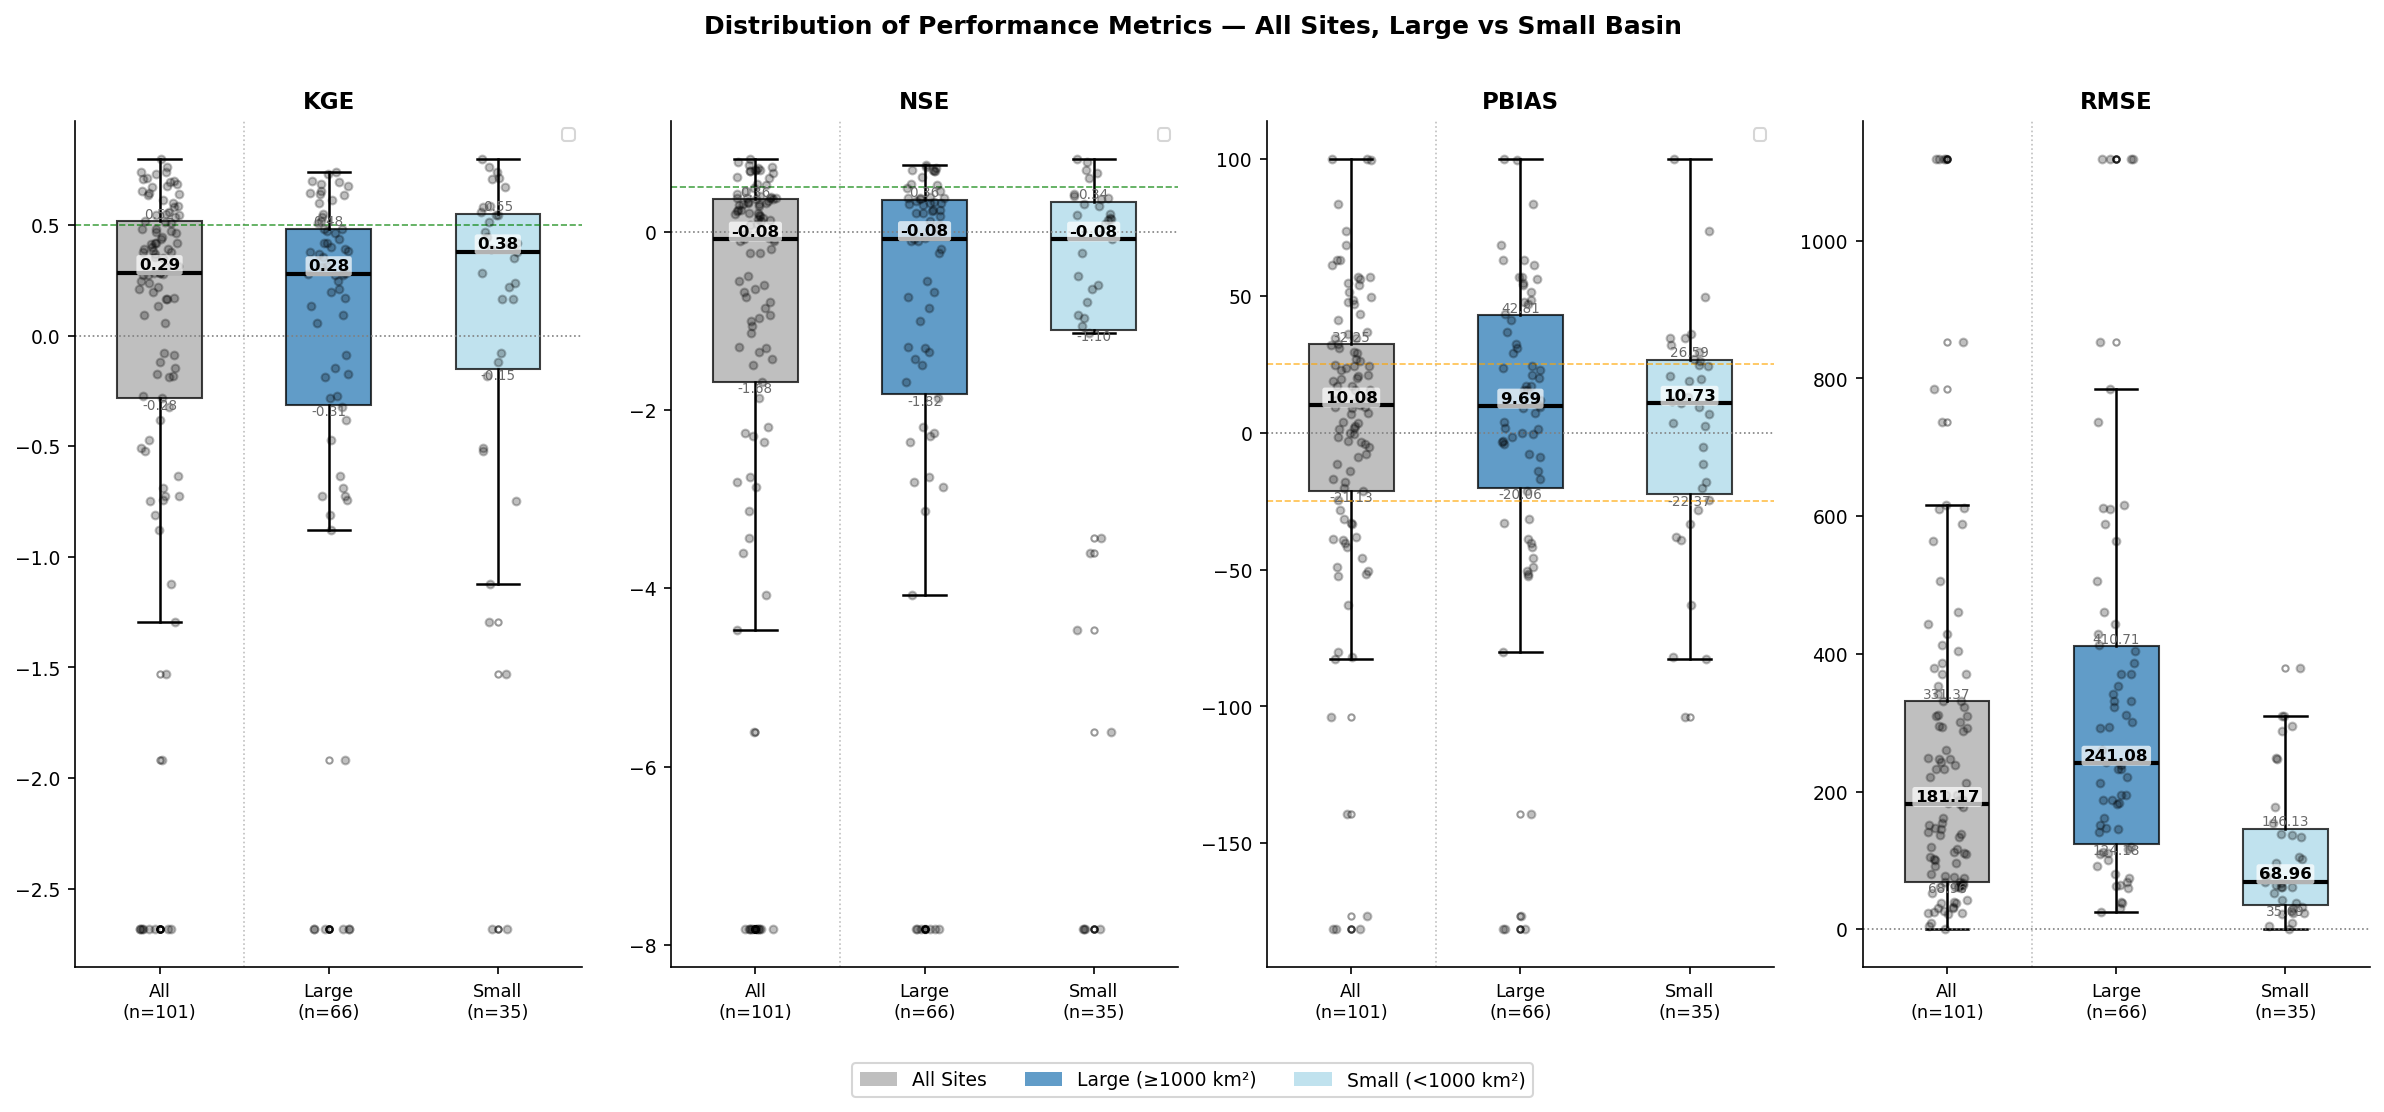

  Saved → Final_Outputs\Overall Analysis\Fig03b_BoxPlot_BasinSize_All_Metrics.png


In [300]:
# ── Fig03b — Distribution of Metrics by Basin Size (Large vs Small) ──────────
if 'DA_class' in df_all.columns:
    fig, axes = plt.subplots(1, 4, figsize=(16, 7), sharey=False)

    df_large = df_all[df_all['DA_class'] == 'Large']
    df_small = df_all[df_all['DA_class'] == 'Small']

    for ax, metric in zip(axes, metrics_list):
        d_all   = df_all[metric].dropna()
        d_large = df_large[metric].dropna()
        d_small = df_small[metric].dropna()

        lo, hi  = strip_outliers_for_plot(d_all)

        data_groups = [
            d_all.clip(lo, hi),
            d_large.clip(lo, hi),
            d_small.clip(lo, hi)
        ]

        bp = ax.boxplot(
            data_groups,
            positions=[1, 2, 3],
            patch_artist=True,
            widths=0.5,
            notch=False,
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
            flierprops=dict(marker='o', markersize=3, alpha=0.4)
        )

        ax.set_title(metric, fontsize=11, fontweight='bold', pad=6)

        # Colors: gray=All, dark teal=Large, light teal=Small
        box_colors = ['#aaaaaa', '#2c7bb6', '#abd9e9']
        for patch, col in zip(bp['boxes'], box_colors):
            patch.set_facecolor(col)
            patch.set_alpha(0.75)

        # Jittered raw data points
        for pos, data in zip([1, 2, 3], data_groups):
            jitter = np.random.uniform(-0.12, 0.12, size=len(data))
            ax.scatter(pos + jitter, data,
                       alpha=0.25, s=14, color='black', zorder=3)

        # Median annotations
        annotate_medians(ax, data_groups, positions=[1, 2, 3])

        # Q1 / Q3 annotations
        for pos, data in zip([1, 2, 3], data_groups):
            q1 = np.nanpercentile(data, 25)
            q3 = np.nanpercentile(data, 75)
            ax.text(pos, q1, f'{q1:.2f}', ha='center', va='top',
                    fontsize=6.5, color='dimgray')
            ax.text(pos, q3, f'{q3:.2f}', ha='center', va='bottom',
                    fontsize=6.5, color='dimgray')

        # X-axis labels
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels([
            f'All\n(n={len(d_all)})',
            f'Large\n(n={len(d_large)})',
            f'Small\n(n={len(d_small)})'
        ], fontsize=8.5)

        # Separator between All and the two DA groups
        ax.axvline(1.5, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)

        # Reference lines
        if metric in ('KGE', 'NSE'):
            ax.axhline(0.5, color='green', linewidth=0.8,
                       linestyle='--', alpha=0.7)
            ax.axhline(0,   color='gray',  linewidth=0.8, linestyle=':')
            ax.legend(fontsize=7.5)
        elif metric == 'PBIAS':
            ax.axhline( 25, color='orange', linewidth=0.8,
                        linestyle='--', alpha=0.7)
            ax.axhline(-25, color='orange', linewidth=0.8,
                        linestyle='--', alpha=0.7)
            ax.axhline(0,   color='gray',   linewidth=0.8, linestyle=':')
            ax.legend(fontsize=7.5)
        else:
            ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')

    # Shared legend
    legend_patches = [
        mpatches.Patch(facecolor='#aaaaaa', alpha=0.75,
                       label='All Sites'),
        mpatches.Patch(facecolor='#2c7bb6', alpha=0.75,
                       label=f'Large (≥{DA_THRESHOLD_SQKM} km²)'),
        mpatches.Patch(facecolor='#abd9e9', alpha=0.75,
                       label=f'Small (<{DA_THRESHOLD_SQKM} km²)'),
    ]
    fig.legend(handles=legend_patches, loc='lower center',
               ncol=3, fontsize=9, framealpha=0.8,
               bbox_to_anchor=(0.5, -0.06))

    fig.suptitle(
        f'Distribution of Performance Metrics — All Sites, Large vs Small Basin\n',
        fontweight='bold'
    )

    save_fig(fig, os.path.join(OUT_OVERALL,
             'Fig03b_BoxPlot_BasinSize_All_Metrics.png'))

else:
    print("Skipping Fig03b — DA_class not available.")

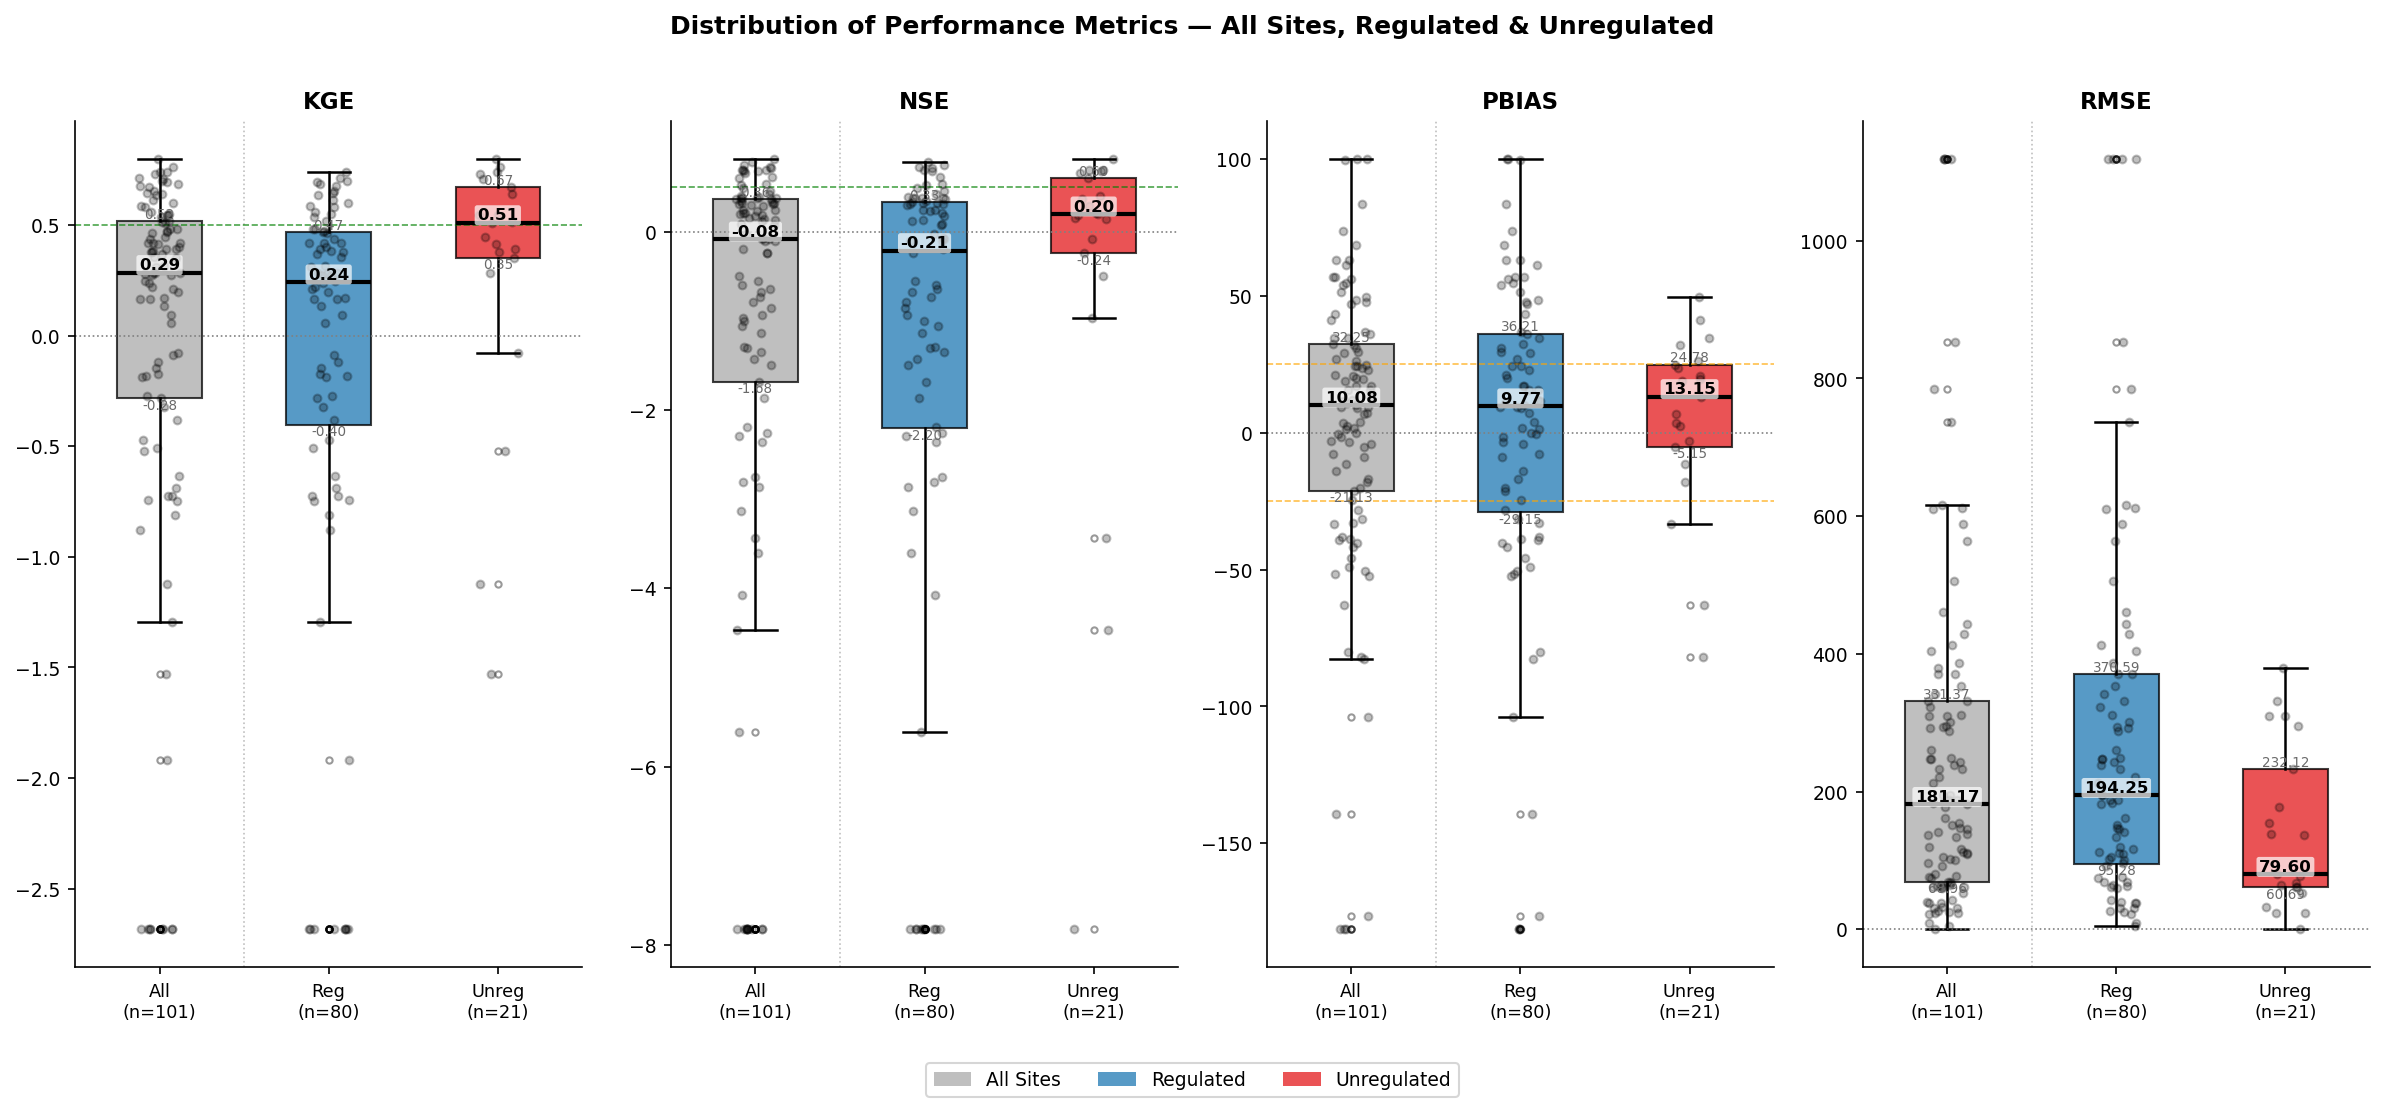

  Saved → Final_Outputs\Overall Analysis\Fig03_BoxPlot_Reg_Unreg_All_Metrics.png


In [301]:
fig, axes = plt.subplots(1, 4, figsize=(16, 7))

for ax, metric in zip(axes, metrics_list):
    d_all   = df_all[metric].dropna()
    d_reg   = df_reg_m[metric].dropna()
    d_unreg = df_unreg_m[metric].dropna()

    lo, hi  = strip_outliers_for_plot(d_all)

    # 3 groups: All, Regulated, Unregulated
    data_groups = [
        d_all.clip(lo, hi),
        d_reg.clip(lo, hi),
        d_unreg.clip(lo, hi)
    ]

    bp = ax.boxplot(
        data_groups,
        positions=[1, 2, 3],
        patch_artist=True,
        widths=0.5,
        notch=False,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=3, alpha=0.4)
    )

    # Colors: gray for All, blue for Reg, red for Unreg
    box_colors = ['#aaaaaa', REG_COLOR, UNREG_COLOR]
    for patch, col in zip(bp['boxes'], box_colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.75)

    # Jittered raw data points
    for pos, data in zip([1, 2, 3], data_groups):
        jitter = np.random.uniform(-0.12, 0.12, size=len(data))
        ax.scatter(
            pos + jitter, data,
            alpha=0.25, s=14, color='black', zorder=3
        )

    # Median annotations
    annotate_medians(ax, data_groups, positions=[1, 2, 3])

    # Q1 / Q3 annotations
    for pos, data in zip([1, 2, 3], data_groups):
        q1 = np.nanpercentile(data, 25)
        q3 = np.nanpercentile(data, 75)
        ax.text(
            pos, q1, f'{q1:.2f}',
            ha='center', va='top',
            fontsize=6.5, color='dimgray'
        )
        ax.text(
            pos, q3, f'{q3:.2f}',
            ha='center', va='bottom',
            fontsize=6.5, color='dimgray'
        )

    # X-axis labels with n counts
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(
        [
            f'All\n(n={len(d_all)})',
            f'Reg\n(n={len(d_reg)})',
            f'Unreg\n(n={len(d_unreg)})'
        ],
        fontsize=8.5
    )

    # Separator between All and Reg/Unreg groups
    ax.axvline(1.5, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)

    # Reference lines (no labels → no threshold in legend)
    if metric in ('KGE', 'NSE'):
        ax.axhline(0.5, color='green', linewidth=0.8,
                   linestyle='--', alpha=0.7)
        ax.axhline(0,   color='gray',  linewidth=0.8, linestyle=':')
    elif metric == 'PBIAS':
        ax.axhline( 25, color='orange', linewidth=0.8,
                    linestyle='--', alpha=0.7)
        ax.axhline(-25, color='orange', linewidth=0.8,
                    linestyle='--', alpha=0.7)
        ax.axhline(0,   color='gray',   linewidth=0.8, linestyle=':')
    else:
        ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')

    # Panel title = metric name
    ax.set_title(metric, fontsize=11, fontweight='bold', pad=6)

# Shared legend for fill colors only
legend_patches = [
    mpatches.Patch(facecolor='#aaaaaa', alpha=0.75, label='All Sites'),
    mpatches.Patch(facecolor=REG_COLOR,   alpha=0.75, label='Regulated'),
    mpatches.Patch(facecolor=UNREG_COLOR, alpha=0.75, label='Unregulated'),
]
fig.legend(
    handles=legend_patches,
    loc='lower center',
    ncol=3, fontsize=9, framealpha=0.8,
    bbox_to_anchor=(0.5, -0.06)
)

fig.suptitle(
    'Distribution of Performance Metrics — All Sites, Regulated & Unregulated\n',
    fontweight='bold'
)

save_fig(fig, os.path.join(OUT_OVERALL, 'Fig03_BoxPlot_Reg_Unreg_All_Metrics.png'))

In [302]:
# ══════════════════════════════════════════════════════════════════════════════
# Hypothesis Testing — Performance Metrics by Basin Size (Large vs Small)
# ══════════════════════════════════════════════════════════════════════════════
from scipy import stats
from scipy.stats import mannwhitneyu, shapiro, levene
from scipy.stats import permutation_test as scipy_permutation_test
from statsmodels.stats.power import TTestIndPower
import numpy as np

# ── 0. Config ─────────────────────────────────────────────────────────────────
alpha       = 0.05
alternative = 'two-sided'   # 'two-sided' | 'greater' | 'less'
seed        = 100
n_resamples = 5000
metrics_list1 = ['KGE']

print(f"Configured alternative hypothesis : {alternative}")
print(f"Significance level (alpha)        : {alpha}")


# ── 1. Hypotheses ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("HYPOTHESES")
print("="*70)
for metric in metrics_list1:
    print(f"\n  Metric: {metric}")
    print(f"  H0 : The median {metric} for Large and Small basins are equal.")
    if alternative == 'two-sided':
        print(f"  H1 : The median {metric} for Large and Small basins are NOT equal.")
    elif alternative == 'greater':
        print(f"  H1 : The median {metric} for Large basins > Small basins.")
    elif alternative == 'less':
        print(f"  H1 : The median {metric} for Large basins < Small basins.")


# ── 2. Helper functions (following example notebook pattern) ──────────────────
def run_shapiro(data, label):
    """Shapiro-Wilk normality test."""
    stat, p = shapiro(data.dropna())
    normal = p > alpha
    return {'label': label, 'statistic': stat, 'p_value': p, 'normal': normal}

def run_levene(g1, g2):
    """Levene test for equal variances."""
    stat, p = levene(g1.dropna(), g2.dropna())
    equal_var = p > alpha
    return {'statistic': stat, 'p_value': p, 'equal_var': equal_var}

def run_welch_ttest(g1, g2, alternative='two-sided'):
    stat, p = stats.ttest_ind(g1.dropna(), g2.dropna(),
                              equal_var=False, alternative=alternative)
    return {'test_name': "Welch's t-test", 'statistic': stat, 'p_value': p}

def run_mannwhitney(g1, g2, alternative='two-sided'):
    stat, p = mannwhitneyu(g1.dropna(), g2.dropna(), alternative=alternative)
    return {'test_name': "Mann-Whitney U", 'statistic': stat, 'p_value': p}

def run_permutation(g1, g2, alternative='two-sided',
                    n_resamples=5000, random_state=42):
    def diff_medians(x, y):
        return np.median(x) - np.median(y)
    res = scipy_permutation_test(
        (g1.dropna().values, g2.dropna().values),
        diff_medians,
        permutation_type='independent',
        n_resamples=n_resamples,
        alternative=alternative,
        random_state=random_state
    )
    return {'test_name': "Permutation test (diff medians)",
            'statistic': res.statistic, 'p_value': res.pvalue}

def cohen_d(g1, g2):
    """Pooled Cohen's d."""
    n1, n2 = len(g1), len(g2)
    s1, s2 = g1.std(ddof=1), g2.std(ddof=1)
    sp = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    d  = (g1.mean() - g2.mean()) / sp
    return d, sp

def estimate_power(effect_size, n1, n2, alpha, alternative):
    analysis = TTestIndPower()
    alt_label = {'two-sided': 'two-sided',
                 'greater': 'larger', 'less': 'smaller'}[alternative]
    pwr = analysis.power(effect_size=abs(effect_size),
                         nobs1=n1, alpha=alpha,
                         ratio=n2/n1, alternative=alt_label)
    return float(np.squeeze(pwr))

def required_n(effect_size, alpha, alternative, target_power=0.80):
    analysis = TTestIndPower()
    alt_label = {'two-sided': 'two-sided',
                 'greater': 'larger', 'less': 'smaller'}[alternative]
    n = analysis.solve_power(effect_size=abs(effect_size),
                             power=target_power, alpha=alpha,
                             ratio=1.0, alternative=alt_label)
    return int(np.ceil(float(np.squeeze(n))))


# ── 3. Split groups ───────────────────────────────────────────────────────────
# events_out has columns: site_no, classification, year, obs_peak, sim_peak,
#                         threshold_m3s, above_threshold, KGE, NSE, PBIAS, RMSE
site_meta   = df_all.reset_index()[['site_no', 'DA_class']].drop_duplicates('site_no')
events_test = events_out.merge(site_meta, on='site_no', how='left')

df_large = events_test[events_test['DA_class'] == 'Large']
df_small = events_test[events_test['DA_class'] == 'Small']

print(f"\nGroup sizes  →  Large: {len(df_large)}  |  Small: {len(df_small)}")


# ── 4. Main loop — one block per metric ──────────────────────────────────────
results_summary = []

for metric in metrics_list1:
    g_large = df_large[metric].dropna()
    g_small = df_small[metric].dropna()

    sep = "="*70
    print(f"\n{sep}")
    print(f"  METRIC : {metric}   (Large n={len(g_large)}, Small n={len(g_small)})")
    print(sep)

    # ── 4a. Descriptive stats ─────────────────────────────────────────────────
    print(f"\n  Descriptive Statistics:")
    print(f"  {'':12s}  {'Mean':>10s}  {'Median':>10s}  {'Std':>10s}")
    print(f"  {'Large':12s}  {g_large.mean():>10.4f}  {g_large.median():>10.4f}  {g_large.std():>10.4f}")
    print(f"  {'Small':12s}  {g_small.mean():>10.4f}  {g_small.median():>10.4f}  {g_small.std():>10.4f}")

    # ── 4b. Normality (Shapiro-Wilk) ─────────────────────────────────────────
    sw_large = run_shapiro(g_large, 'Large')
    sw_small = run_shapiro(g_small, 'Small')
    print(f"\n  Shapiro-Wilk Normality Test (H0: data is normally distributed):")
    for sw in [sw_large, sw_small]:
        verdict = "Normal" if sw['normal'] else "Non-normal"
        print(f"  {sw['label']:8s} | W={sw['statistic']:.4f} | p={sw['p_value']:.4f} | → {verdict}")

    # ── 4c. Levene variance test ──────────────────────────────────────────────
    lev = run_levene(g_large, g_small)
    var_verdict = "Equal variances" if lev['equal_var'] else "Unequal variances"
    print(f"\n  Levene Test for Equal Variances:")
    print(f"  stat={lev['statistic']:.4f} | p={lev['p_value']:.4f} | → {var_verdict}")

    # ── 4d. Three hypothesis tests ────────────────────────────────────────────
    welch = run_welch_ttest(g_large, g_small, alternative)
    mwu   = run_mannwhitney(g_large, g_small, alternative)
    perm  = run_permutation(g_large, g_small, alternative,
                            n_resamples=n_resamples, random_state=seed)

    print(f"\n  Hypothesis Tests  (alpha={alpha}, alternative='{alternative}'):")
    print(f"  {'-'*66}")
    print(f"  {'Test':38s} | {'Statistic':>12s} | {'p-value':>8s} | Decision")
    print(f"  {'-'*66}")
    for r in [welch, mwu, perm]:
        dec = 'Reject H0' if r['p_value'] <= alpha else 'Fail to reject H0'
        print(f"  {r['test_name']:38s} | {r['statistic']:>12.4f} | {r['p_value']:>8.4f} | {dec}")

    # Use MWU p-value as primary decision (non-parametric, appropriate for metrics)
    primary_p = mwu['p_value']
    decision  = 'Reject H0' if primary_p <= alpha else 'Fail to reject H0'

    # ── 4e. Effect size & Power ───────────────────────────────────────────────
    d, sp = cohen_d(g_large, g_small)
    n1, n2 = len(g_large), len(g_small)
    power  = estimate_power(d, n1, n2, alpha, alternative)
    beta   = 1 - power
    req    = required_n(d, alpha, alternative)

    print(f"\n  Effect Size & Power (two-sample t approximation):")
    print(f"  Pooled std (sp)             : {sp:.4f}")
    print(f"  Cohen's d (Large - Small)   : {d:.4f}")
    print(f"  Estimated power             : {power:.4f}")
    print(f"  Estimated Type II error (β) : {beta:.4f}")
    print(f"  Required n/group for 80% pw : {req}")

    # ── 4f. Final interpretation ──────────────────────────────────────────────
    print(f"\n  Decision (primary — MWU): {decision}")
    print(f"  - Type I  error risk (α)  controlled at {alpha:.2f}.")
    print(f"  - Type II error risk (β) ≈ {beta:.3f}  (power ≈ {power:.3f}).")
    if decision == 'Reject H0':
        print(f"  - p ≤ α → statistically significant difference in {metric} "
              f"between Large and Small basins.")
    else:
        print(f"  - p > α → insufficient evidence of a significant difference in {metric}.")
        print(f"    (Low power does not confirm H0; a real effect may exist.)")


    results_summary.append({
        'Metric': metric,
        'n_Large': n1, 'n_Small': n2,
        'Mean_Large': g_large.mean(), 'Mean_Small': g_small.mean(),
        'Median_Large': g_large.median(), 'Median_Small': g_small.median(),
        'Shapiro_Large_p': sw_large['p_value'], 'Shapiro_Small_p': sw_small['p_value'],
        'Levene_p': lev['p_value'],
        'Welch_p': welch['p_value'],
        'MWU_p': mwu['p_value'],
        'Perm_p': perm['p_value'],
        'CohenD': d, 'Power': power, 'Beta': beta,
        'Decision': decision,
    })

# ── 5. Summary table ──────────────────────────────────────────────────────────
print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)
df_summary = pd.DataFrame(results_summary)
display(df_summary[[
    'Metric', 'n_Large', 'n_Small',
    'Median_Large', 'Median_Small',
    'MWU_p', 'Welch_p', 'Perm_p',
    'CohenD', 'Power', 'Beta', 'Decision'
]].round(4))

Configured alternative hypothesis : two-sided
Significance level (alpha)        : 0.05

HYPOTHESES

  Metric: KGE
  H0 : The median KGE for Large and Small basins are equal.
  H1 : The median KGE for Large and Small basins are NOT equal.

Group sizes  →  Large: 1507  |  Small: 767

  METRIC : KGE   (Large n=1507, Small n=767)

  Descriptive Statistics:
                      Mean      Median         Std
  Large            -0.4692      0.2830      2.5056
  Small            -0.0870      0.3905      1.2338

  Shapiro-Wilk Normality Test (H0: data is normally distributed):
  Large    | W=0.4274 | p=0.0000 | → Non-normal
  Small    | W=0.6298 | p=0.0000 | → Non-normal

  Levene Test for Equal Variances:
  stat=10.9673 | p=0.0009 | → Unequal variances

  Hypothesis Tests  (alpha=0.05, alternative='two-sided'):
  ------------------------------------------------------------------
  Test                                   |    Statistic |  p-value | Decision
  ------------------------------------

,Metric,n_Large,n_Small,Median_Large,Median_Small,MWU_p,Welch_p,Perm_p,CohenD,Power,Beta,Decision
0,KGE,1507,767,0.283,0.3905,0.0,0.0,0.0004,-0.1768,0.9785,0.0215,Reject H0


## 📊 Overall Figure 4 — % Sites Meeting Performance Thresholds

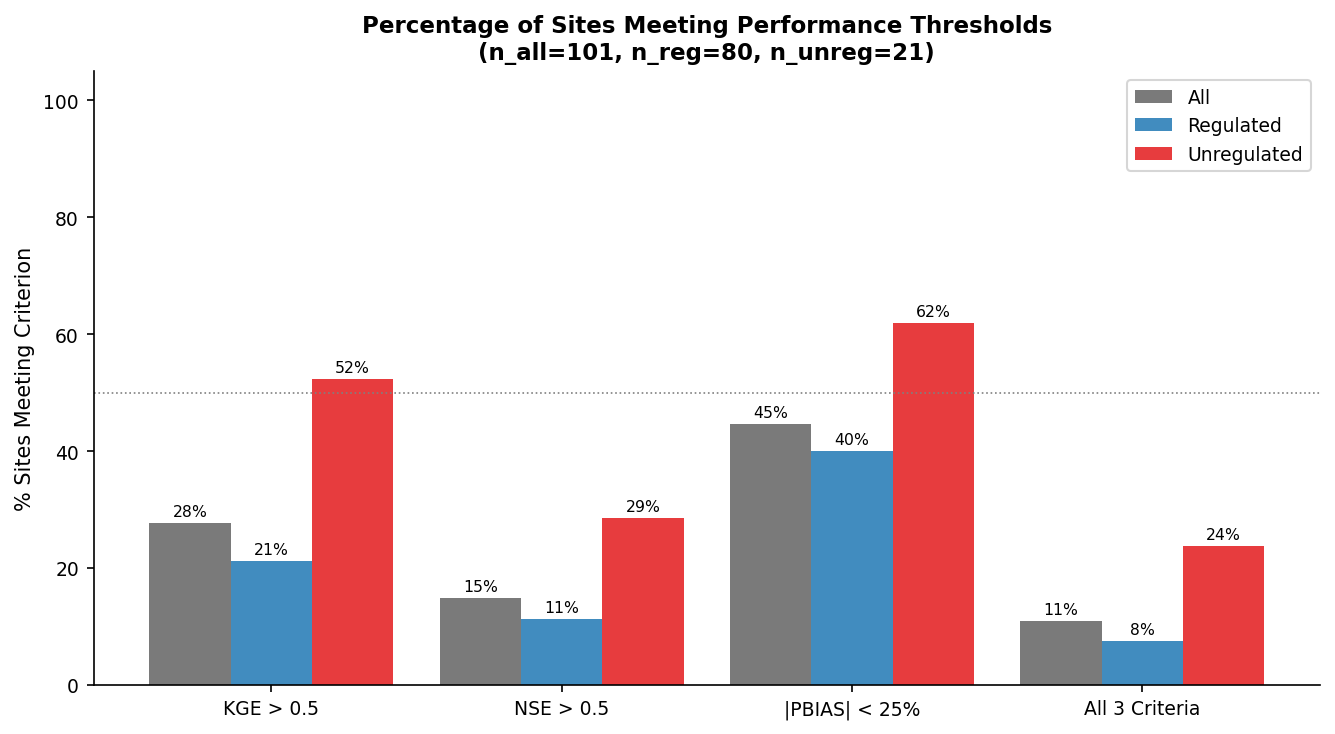

  Saved → Final_Outputs\Overall Analysis\Fig04_Pct_Sites_Performance_Thresholds.png


In [303]:
def pct_meeting(df, kge_thr=KGE_THRESHOLD,
                nse_thr=NSE_THRESHOLD, pbias_thr=PBIAS_THRESHOLD):
    n = len(df.dropna(subset=['KGE']))
    if n == 0:
        return {'KGE': 0, 'NSE': 0, 'PBIAS': 0, 'All': 0, 'n': 0}
    return {
        'KGE':  100*(df['KGE'].dropna()  >= kge_thr).mean(),
        'NSE':  100*(df['NSE'].dropna()  >= nse_thr).mean(),
        'PBIAS':100*(df['PBIAS'].dropna().abs() <= pbias_thr).mean(),
        'All':  100*(
            (df['KGE']  >= kge_thr) &
            (df['NSE']  >= nse_thr) &
            (df['PBIAS'].abs() <= pbias_thr)
        ).sum() / n,
        'n': n
    }

pct_all   = pct_meeting(df_all)
pct_reg   = pct_meeting(df_reg_m)
pct_unreg = pct_meeting(df_unreg_m)

groups  = ['KGE > 0.5', 'NSE > 0.5', '|PBIAS| < 25%', 'All 3 Criteria']
keys    = ['KGE', 'NSE', 'PBIAS', 'All']
x       = np.arange(len(groups))
width   = 0.28

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width,   [pct_all[k]   for k in keys], width, label='All',
       color='#636363', alpha=0.85)
ax.bar(x,           [pct_reg[k]   for k in keys], width, label='Regulated',
       color=REG_COLOR, alpha=0.85)
ax.bar(x + width,   [pct_unreg[k] for k in keys], width, label='Unregulated',
       color=UNREG_COLOR, alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(groups, fontsize=9)
ax.set_ylabel('% Sites Meeting Criterion')
ax.set_ylim(0, 105)
ax.axhline(50, color='gray', linewidth=0.8, linestyle=':')
ax.legend()
ax.set_title(f'Percentage of Sites Meeting Performance Thresholds\n'
             f'(n_all={pct_all["n"]}, n_reg={pct_reg["n"]}, '
             f'n_unreg={pct_unreg["n"]})',
             fontweight='bold')

# value labels
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f%%', fontsize=7.5, padding=2)

save_fig(fig, os.path.join(OUT_OVERALL, 'Fig04_Pct_Sites_Performance_Thresholds.png'))


## 📉 Overall Figure 5 — Sensitivity Analysis: KGE/NSE vs Window Size

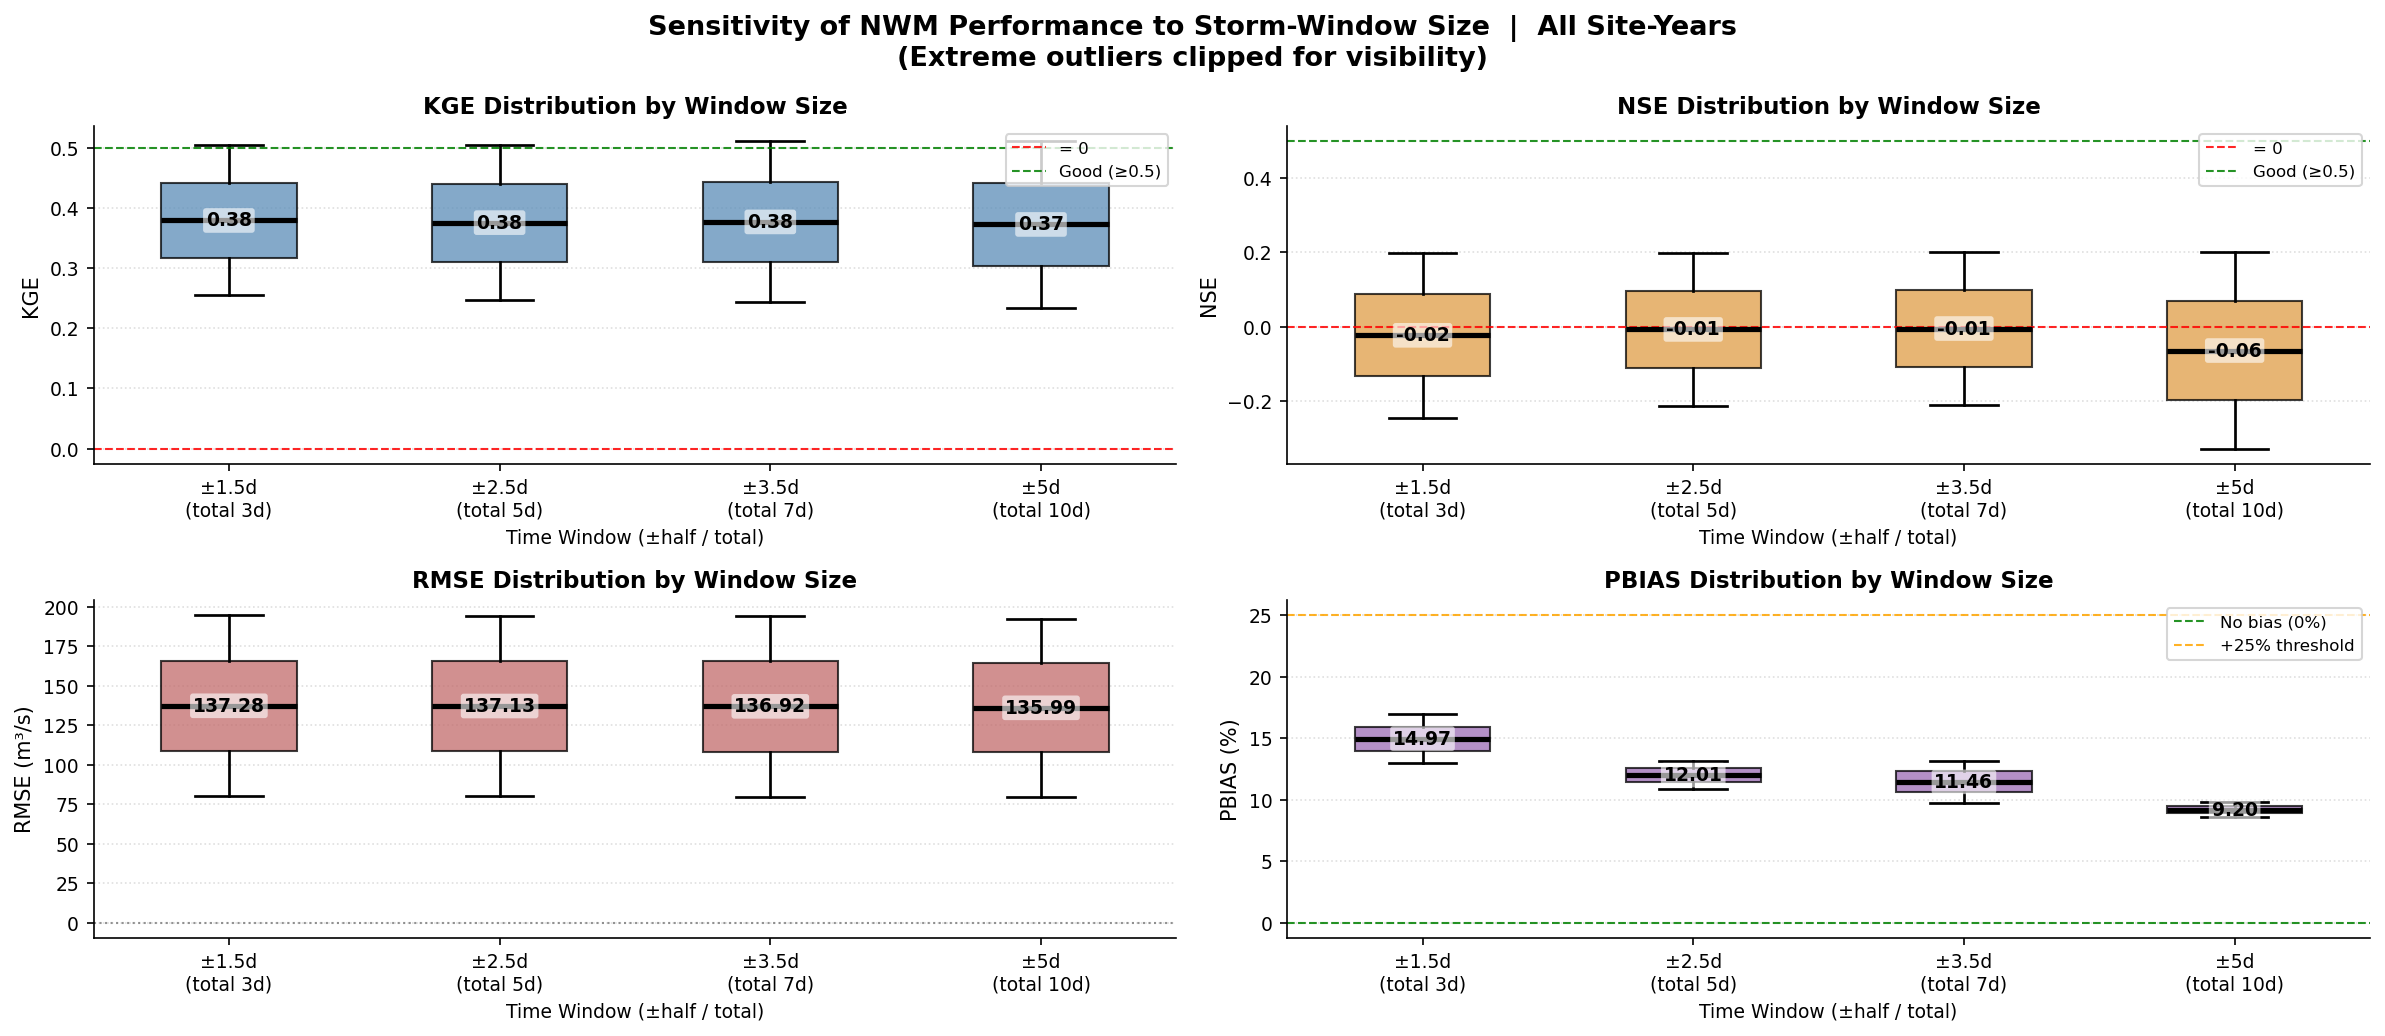

  Saved → Final_Outputs\Overall Analysis\Fig05_Sensitivity_BoxPlot_4Metrics.png


In [304]:
if not sens_df.empty:
    # Use only the 'All' DA_class rows (site-aggregated, no DA split)
    sens_all = sens_df[sens_df['DA_class'] == 'All'].copy()

    metric_cfg = {
        'median_KGE':   dict(label='KGE',       color='#5b8db8', ylabel='KGE',
                             refs=[(0, 'red', '--', '= 0'),
                                   (0.5, 'green', '--', 'Good (≥0.5)')]),
        'median_NSE':   dict(label='NSE',       color='#e09c45', ylabel='NSE',
                             refs=[(0, 'red', '--', '= 0'),
                                   (0.5, 'green', '--', 'Good (≥0.5)')]),
        'median_RMSE':  dict(label='RMSE',      color='#c26b6b', ylabel='RMSE (m³/s)',
                             refs=[(0, 'gray', ':', '')]),
        'median_PBIAS': dict(label='PBIAS',     color='#9b6bb5', ylabel='PBIAS (%)',
                             refs=[(0,   'green',  '--', 'No bias (0%)'),
                                   ( 25, 'orange', '--', '+25% threshold'),]),
    }

    fig, axes = plt.subplots(2, 2, figsize=(16, 7), sharey=False)
    axes = axes.flatten()

    # Build x-tick labels matching your reference: ±Xd (total Yd)
    def window_label(w):
        half = w / 2
        half_str = f'{half:.0f}' if half == int(half) else f'{half:.1f}'
        return f'±{half_str}d\n(total {w}d)'

    for ax, (metric, cfg) in zip(axes, metric_cfg.items()):
        box_data  = []
        xtick_labels = []

        for w in SENSITIVITY_WINDOWS:
            # Collect site-level metric values across both classes for this window
            vals = sens_all[sens_all['window_days'] == w][metric].dropna()
            if vals.empty:
                # Fallback: pull from full sens_df for this window
                vals = sens_df[(sens_df['window_days'] == w) &
                               (sens_df['DA_class'] == 'All')][metric].dropna()
            box_data.append(vals.values if len(vals) else np.array([np.nan]))
            xtick_labels.append(window_label(w))

        # Clip outliers (5–95th pct) for visibility
        all_vals = np.concatenate([d for d in box_data if len(d)])
        lo = np.nanpercentile(all_vals, 5)
        hi = np.nanpercentile(all_vals, 95)
        box_data_clipped = [np.clip(d, lo, hi) for d in box_data]

        bp = ax.boxplot(
            box_data_clipped,
            patch_artist=True,
            widths=0.5,
            medianprops=dict(color='black', linewidth=2.5),
            whiskerprops=dict(linewidth=1.3),
            capprops=dict(linewidth=1.3),
            flierprops=dict(marker='.', markersize=4, alpha=0.4,
                            markerfacecolor='black')
        )
        for patch in bp['boxes']:
            patch.set_facecolor(cfg['color'])
            patch.set_alpha(0.75)

        # Median value label inside box
        for i, data in enumerate(box_data_clipped, start=1):
            med = np.nanmedian(data)
            ax.text(i, med, f'{med:.2f}',
                    ha='center', va='center',
                    fontsize=9, fontweight='bold', color='black',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white',
                              ec='none', alpha=0.6))

        # Reference lines
        legend_lines = []
        for val, color, ls, lbl in cfg['refs']:
            line = ax.axhline(val, color=color, linewidth=1.0,
                              linestyle=ls, alpha=0.85,
                              label=lbl if lbl else None)
            if lbl:
                legend_lines.append(line)
        if legend_lines:
            ax.legend(handles=legend_lines, fontsize=8, loc='upper right')

        ax.set_xticks(range(1, len(SENSITIVITY_WINDOWS) + 1))
        ax.set_xticklabels(xtick_labels, fontsize=9)
        ax.set_ylabel(cfg['ylabel'], fontsize=10)
        ax.set_title(f'{cfg["label"]} Distribution by Window Size',
                     fontweight='bold', fontsize=11)
        ax.grid(axis='y', linestyle=':', alpha=0.4)
        ax.set_xlabel('Time Window (±half / total)', fontsize=9)

    fig.suptitle(
        'Sensitivity of NWM Performance to Storm-Window Size  |  All Site-Years\n'
        '(Extreme outliers clipped for visibility)',
        fontweight='bold', fontsize=13
    )
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    save_fig(fig, os.path.join(OUT_OVERALL,
             'Fig05_Sensitivity_BoxPlot_4Metrics.png'))
else:
    print("No sensitivity data — skipping figure.")

## 📦 Regulated Figure 6 — Box Plots (Reg only, all metrics)

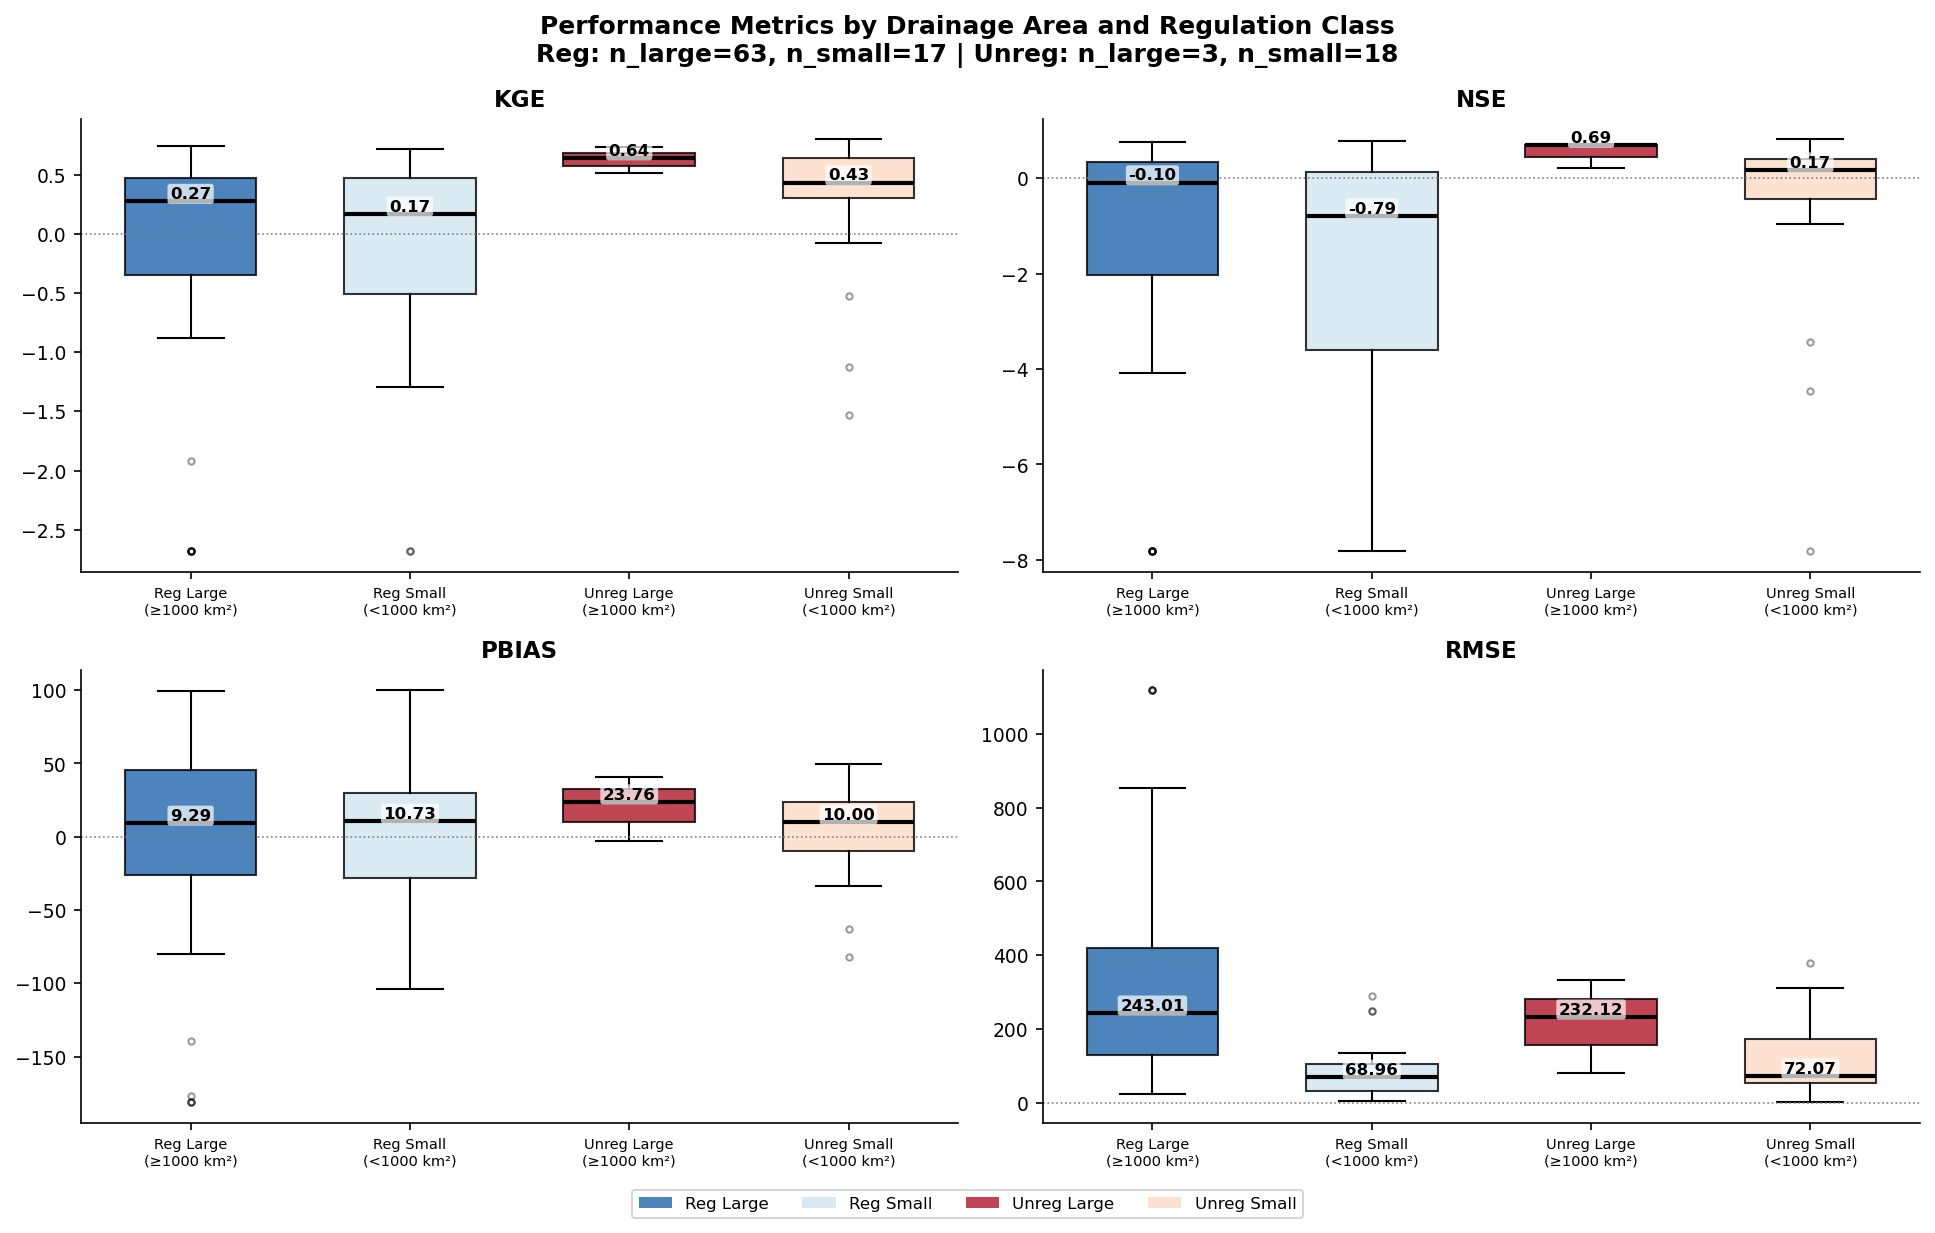

  Saved → Final_Outputs\Overall Analysis\Fig06_08_Combined_DA_RegUnreg_2x2_by_metric.png


In [305]:
# 2x2: one metric per cell, 4 boxes per metric
# Boxes: Reg-Large, Reg-Small, Unreg-Large, Unreg-Small (in that order)

if ('DA_class' in df_reg_m.columns) and ('DA_class' in df_unreg_m.columns):

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    axes_flat = axes.flatten()   # 4 axes

    # Ensure metrics_list has 4 metrics in desired order
    for ax, metric in zip(axes_flat, metrics_list):

        # ── Extract data for this metric ───────────────────────────────
        reg_large   = df_reg_m[df_reg_m['DA_class'] == 'Large'][metric].dropna()
        reg_small   = df_reg_m[df_reg_m['DA_class'] == 'Small'][metric].dropna()
        unreg_large = df_unreg_m[df_unreg_m['DA_class'] == 'Large'][metric].dropna()
        unreg_small = df_unreg_m[df_unreg_m['DA_class'] == 'Small'][metric].dropna()

        # Common clipping range for all four groups for this metric
        all_vals = pd.concat([reg_large, reg_small, unreg_large, unreg_small])
        lo, hi = strip_outliers_for_plot(all_vals.dropna())

        data_groups = [
            reg_large.clip(lo, hi),
            reg_small.clip(lo, hi),
            unreg_large.clip(lo, hi),
            unreg_small.clip(lo, hi),
        ]

        positions = [1, 2, 3, 4]

        bp = ax.boxplot(
            data_groups,
            positions=positions,
            patch_artist=True,
            notch=False,
            widths=0.6,
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(marker='o', markersize=3, alpha=0.4)
        )

        # Colors:
        # Regulated: dark/light blue; Unregulated: dark/light red
        box_colors = ['#2166ac', '#d1e5f0', '#b2182b', '#fddbc7']
        for patch, col in zip(bp['boxes'], box_colors):
            patch.set_facecolor(col)
            patch.set_alpha(0.8)

        # Median annotations
        annotate_medians(ax, data_groups, positions=positions)

        # X-axis tick labels
        ax.set_xticks(positions)
        ax.set_xticklabels(
            [
                f'Reg Large\n(≥{DA_THRESHOLD_SQKM} km²)',
                f'Reg Small\n(<{DA_THRESHOLD_SQKM} km²)',
                f'Unreg Large\n(≥{DA_THRESHOLD_SQKM} km²)',
                f'Unreg Small\n(<{DA_THRESHOLD_SQKM} km²)',
            ],
            fontsize=7
        )

        # Reference line at 0
        ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')

        # Title = metric name
        ax.set_title(metric, fontweight='bold')

    # Overall counts for title
    n_reg_large    = (df_reg_m['DA_class']   == "Large").sum()
    n_reg_small    = (df_reg_m['DA_class']   == "Small").sum()
    n_unreg_large  = (df_unreg_m['DA_class'] == "Large").sum()
    n_unreg_small  = (df_unreg_m['DA_class'] == "Small").sum()

    fig.suptitle(
        'Performance Metrics by Drainage Area and Regulation Class\n'
        f'Reg: n_large={n_reg_large}, n_small={n_reg_small} | '
        f'Unreg: n_large={n_unreg_large}, n_small={n_unreg_small}',
        fontweight='bold'
    )

    # Shared legend for colors
    legend_patches = [
        mpatches.Patch(facecolor='#2166ac', alpha=0.8, label='Reg Large'),
        mpatches.Patch(facecolor='#d1e5f0', alpha=0.8, label='Reg Small'),
        mpatches.Patch(facecolor='#b2182b', alpha=0.8, label='Unreg Large'),
        mpatches.Patch(facecolor='#fddbc7', alpha=0.8, label='Unreg Small'),
    ]
    fig.legend(
        handles=legend_patches,
        loc='lower center',
        ncol=4, fontsize=8, framealpha=0.8,
        bbox_to_anchor=(0.5, -0.03)
    )

    fig.tight_layout(rect=[0, 0.06, 1, 0.92])

    out_path = os.path.join(OUT_OVERALL, 'Fig06_08_Combined_DA_RegUnreg_2x2_by_metric.png')
    save_fig(fig, out_path)

else:
    print("DA_class column missing for regulated or unregulated — skipping combined 2x2 DA plot.")

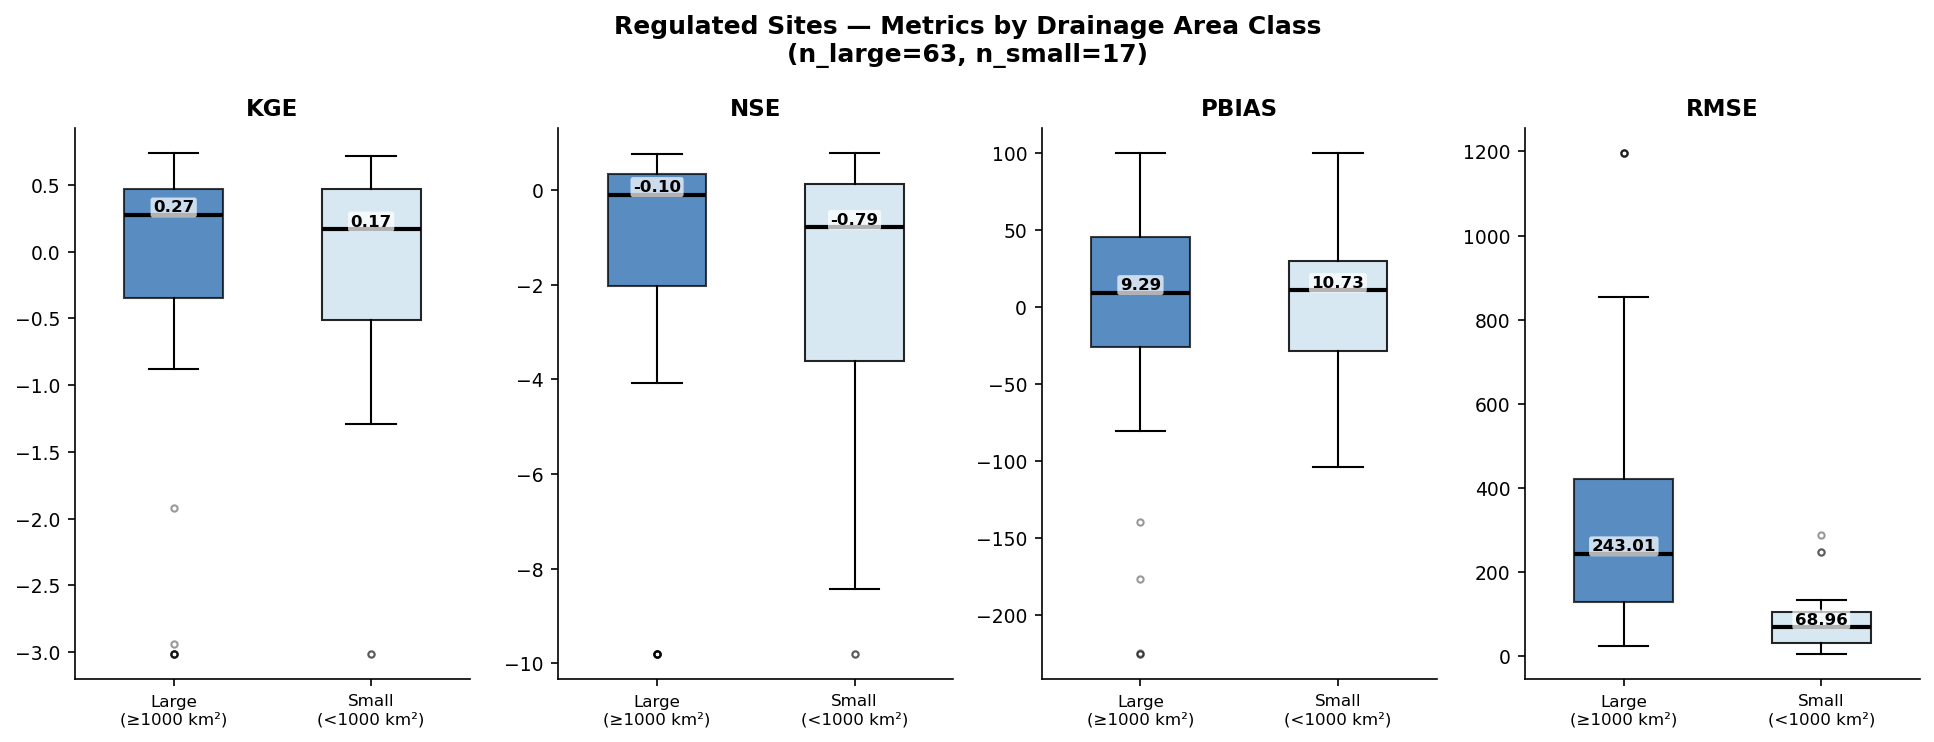

  Saved → Final_Outputs\Regulated\Fig06_Regulated_BoxPlot_by_DA.png


In [306]:
# Side-by-side box by DA class for regulated sites
if 'DA_class' in df_reg_m.columns:
    fig, axes = plt.subplots(1, 4, figsize=(13, 5))
    for ax, metric in zip(axes, metrics_list):
        data_large = df_reg_m[df_reg_m['DA_class']=='Large'][metric].dropna()
        data_small = df_reg_m[df_reg_m['DA_class']=='Small'][metric].dropna()
        lo, hi     = strip_outliers_for_plot(df_reg_m[metric].dropna())
        bp = ax.boxplot(
            [data_large.clip(lo,hi), data_small.clip(lo,hi)],
            patch_artist=True, notch=False, widths=0.5,
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(marker='o', markersize=3, alpha=0.4)
        )
        # ── Median annotations ────────────────────────────────────────────────
        annotate_medians(ax, [data_large.clip(lo, hi), data_small.clip(lo, hi)])
        bp['boxes'][0].set_facecolor('#2166ac'); bp['boxes'][0].set_alpha(0.75)
        bp['boxes'][1].set_facecolor('#d1e5f0'); bp['boxes'][1].set_alpha(0.85)
        ax.set_xticklabels(
            [f'Large\n(≥{DA_THRESHOLD_SQKM} km²)', f'Small\n(<{DA_THRESHOLD_SQKM} km²)'],
            fontsize=8) 
        ax.set_title(metric, fontweight='bold')
    fig.suptitle(f'Regulated Sites — Metrics by Drainage Area Class\n'
                 f'(n_large={len(df_reg_m[df_reg_m.DA_class=="Large"])}, '
                 f'n_small={len(df_reg_m[df_reg_m.DA_class=="Small"])})',
                 fontweight='bold')
    save_fig(fig, os.path.join(OUT_REG, 'Fig06_Regulated_BoxPlot_by_DA.png'))
else:
    print("No DA_class column — skipping regulated DA box plot.")


## 🗺️ Regulated Figure 7 — Median KGE vs Drainage Area

In [307]:
# fig, ax = plt.subplots(figsize=(7, 5))
# sub = df_reg_m.dropna(subset=['KGE', 'drain_area_sqmi'])
# if not sub.empty:
#     sc = ax.scatter(sub['drain_area_sqmi'], sub['KGE'],
#                     c=sub['KGE'], cmap='RdYlGn',
#                     vmin=-2, vmax=1,
#                     s=70, marker='s',
#                     edgecolors='k', linewidths=0.4, alpha=0.8)
#     plt.colorbar(sc, ax=ax, label='KGE')
#     # trend
#     log_da = np.log10(sub['drain_area_sqmi'].clip(lower=1))
#     m, b, r, p, _ = stats.linregress(log_da, sub['KGE'].clip(lower=-5))
#     xs = np.linspace(log_da.min(), log_da.max(), 200)
#     ax.plot(10**xs, m*xs + b, 'b--', linewidth=1.4, label=f'Trend (r={r:.2f})')
#     ax.set_xscale('log')
#     ax.axhline(0,   color='gray',  linewidth=0.8, linestyle=':')
#     ax.axhline(0.5, color='green', linewidth=0.8, linestyle='--', alpha=0.7)
#     ax.set_xlabel('Drainage Area (sq km)'); ax.set_ylabel('KGE')
#     ax.set_title('Regulated Sites: KGE vs Drainage Area', fontweight='bold')
#     ax.legend()
# save_fig(fig, os.path.join(OUT_REG, 'Fig07_Regulated_KGE_vs_DA.png'))


## 📦 Unregulated Figure 8 — Box Plots (Unreg only, all metrics)

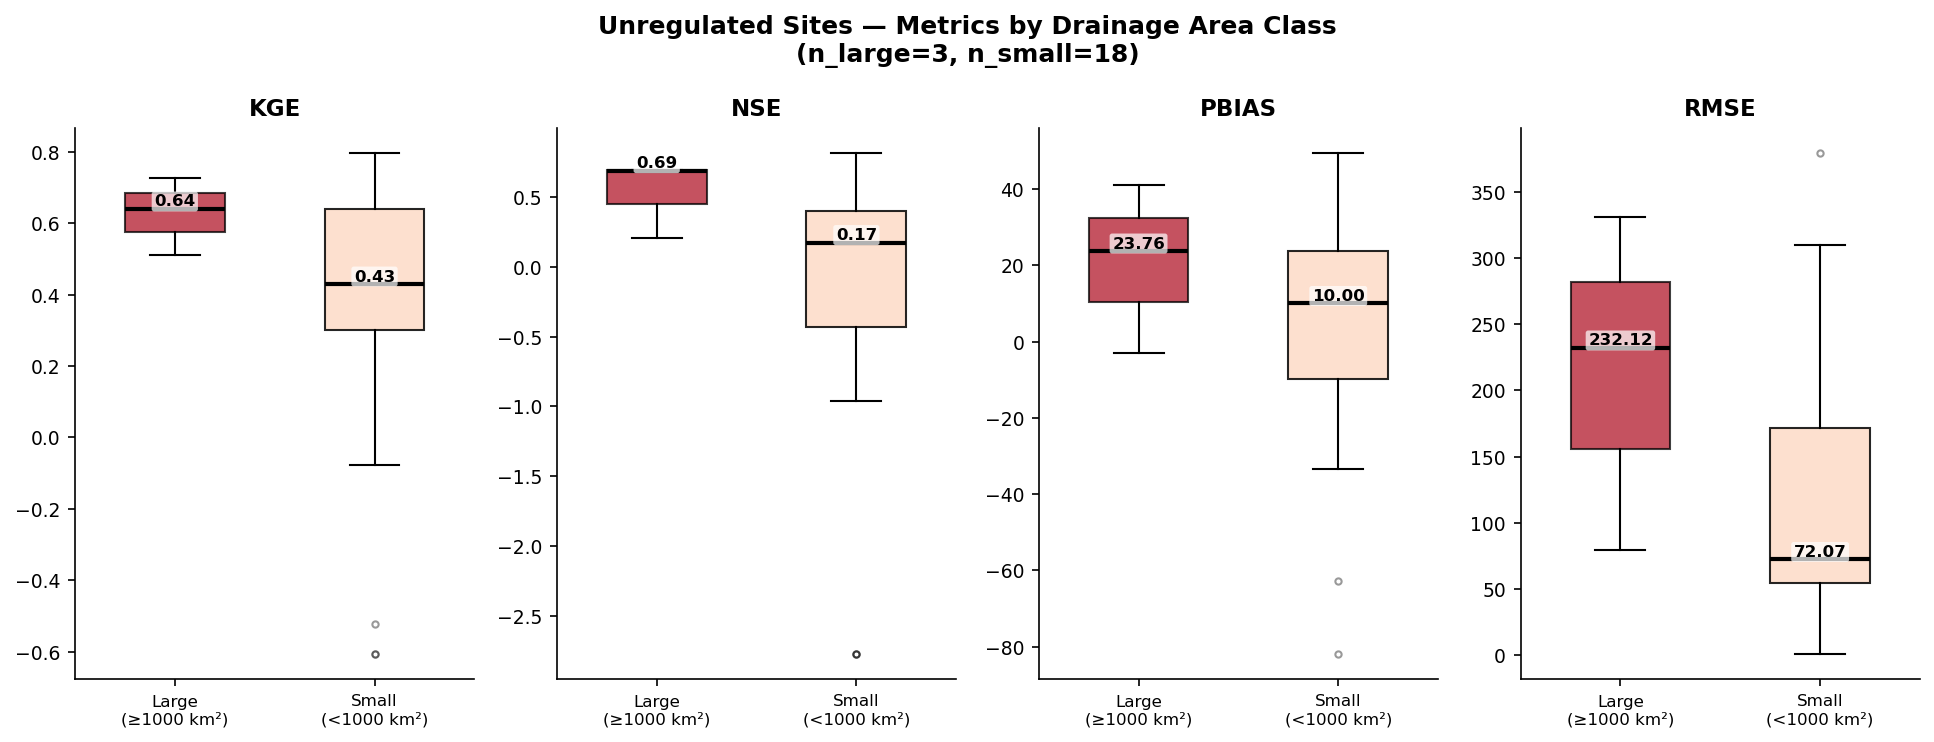

  Saved → Final_Outputs\Unregulated\Fig08_Unregulated_BoxPlot_by_DA.png


In [308]:
if 'DA_class' in df_unreg_m.columns:
    fig, axes = plt.subplots(1, 4, figsize=(13, 5))
    for ax, metric in zip(axes, metrics_list):
        data_large = df_unreg_m[df_unreg_m['DA_class']=='Large'][metric].dropna()
        data_small = df_unreg_m[df_unreg_m['DA_class']=='Small'][metric].dropna()
        lo, hi     = strip_outliers_for_plot(df_unreg_m[metric].dropna())
        bp = ax.boxplot(
            [data_large.clip(lo,hi), data_small.clip(lo,hi)],
            patch_artist=True, notch=False, widths=0.5,
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(marker='o', markersize=3, alpha=0.4)
        )
        # ── Median annotations ────────────────────────────────────────────────
        annotate_medians(ax, [data_large.clip(lo, hi), data_small.clip(lo, hi)])
        bp['boxes'][0].set_facecolor('#b2182b'); bp['boxes'][0].set_alpha(0.75)
        bp['boxes'][1].set_facecolor('#fddbc7'); bp['boxes'][1].set_alpha(0.85)
        ax.set_xticks([1,2]); ax.set_xticklabels(
            [f'Large\n(≥{DA_THRESHOLD_SQKM} km²)',f'Small\n(<{DA_THRESHOLD_SQKM} km²)'],
            fontsize=8)
        ax.set_title(metric, fontweight='bold')
    fig.suptitle(f'Unregulated Sites — Metrics by Drainage Area Class\n'
                 f'(n_large={len(df_unreg_m[df_unreg_m.DA_class=="Large"])}, '
                 f'n_small={len(df_unreg_m[df_unreg_m.DA_class=="Small"])})',
                 fontweight='bold')
    save_fig(fig, os.path.join(OUT_UNREG, 'Fig08_Unregulated_BoxPlot_by_DA.png'))
else:
    print("No DA_class — skipping unregulated DA box plot.")


## 🗺️ Unregulated Figure 9 — Median KGE vs Drainage Area

In [309]:
# fig, ax = plt.subplots(figsize=(7, 5))
# sub = df_unreg_m.dropna(subset=['KGE', 'drain_area_sqmi'])
# if not sub.empty:
#     sc = ax.scatter(sub['drain_area_sqmi'], sub['KGE'],
#                     c=sub['KGE'], cmap='RdYlGn',
#                     vmin=-2, vmax=1,
#                     s=70, marker='o',
#                     edgecolors='k', linewidths=0.4, alpha=0.8)
#     plt.colorbar(sc, ax=ax, label='KGE')
#     log_da = np.log10(sub['drain_area_sqmi'].clip(lower=1))
#     m, b, r, p, _ = stats.linregress(log_da, sub['KGE'].clip(lower=-5))
#     xs = np.linspace(log_da.min(), log_da.max(), 200)
#     ax.plot(10**xs, m*xs + b, 'r--', linewidth=1.4, label=f'Trend (r={r:.2f})')
#     ax.set_xscale('log')
#     ax.axhline(0,   color='gray',  linewidth=0.8, linestyle=':')
#     ax.axhline(0.5, color='green', linewidth=0.8, linestyle='--', alpha=0.7)
#     ax.set_xlabel('Drainage Area (sq km)'); ax.set_ylabel('KGE')
#     ax.set_title('Unregulated Sites: KGE vs Drainage Area', fontweight='bold')
#     ax.legend()
# save_fig(fig, os.path.join(OUT_UNREG, 'Fig09_Unregulated_KGE_vs_DA.png'))


## 📊 Combined Figure 10 — KGE vs DA: Reg vs Unreg Side-by-Side

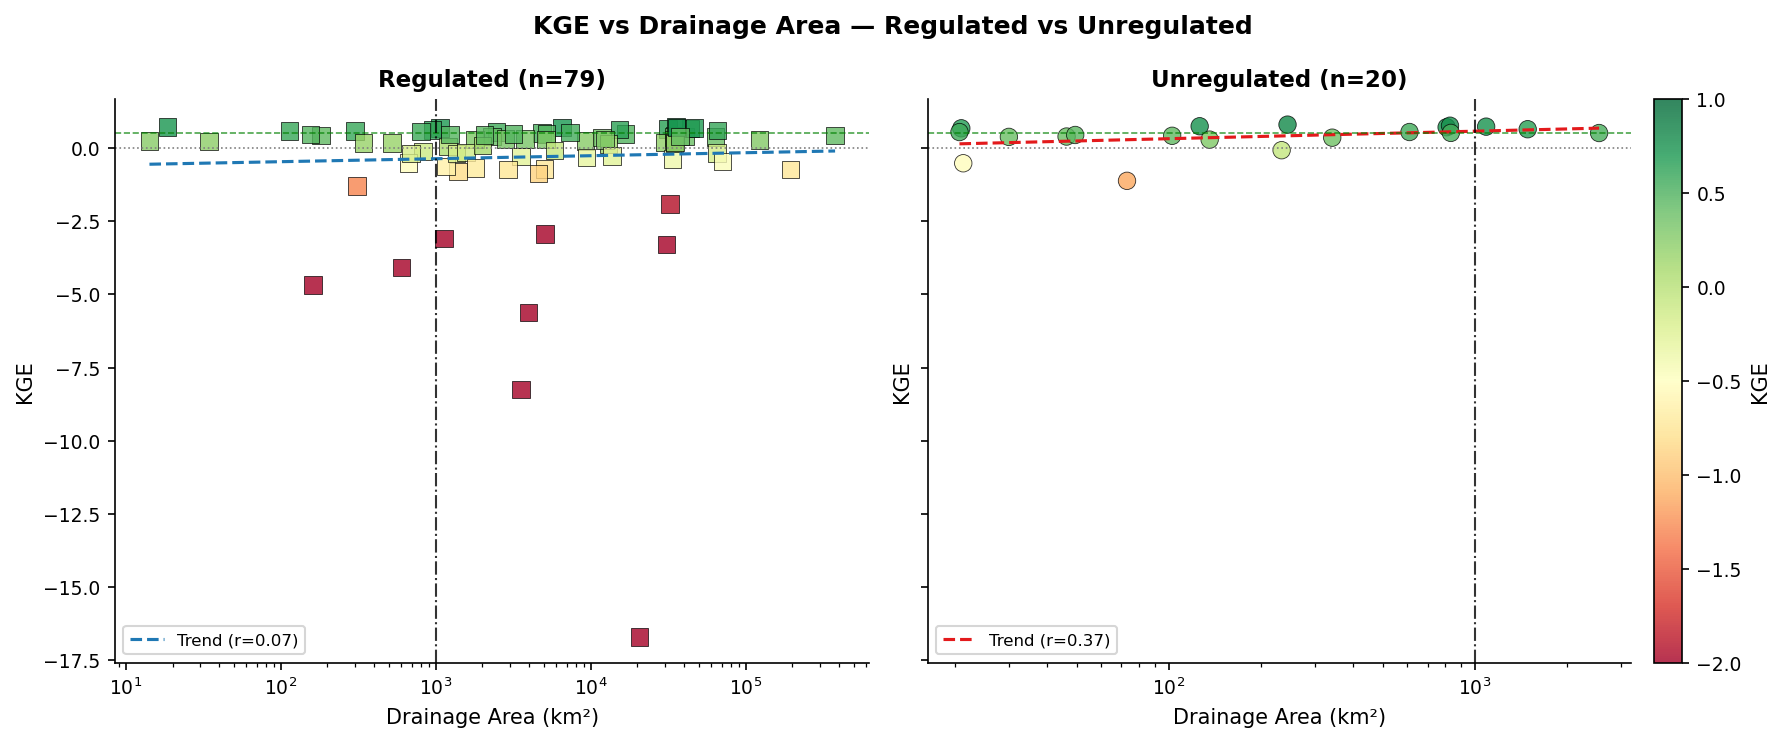

  Saved → Final_Outputs\Overall Analysis\Fig10_KGE_DA_SideBySide_RegVsUnreg.png


In [313]:
# Overall Figure 10 – KGE vs Drainage Area (Reg vs Unreg, single colorbar)

# Convert drainage area from sq mi to sq km
df_all['drain_area_sqkm'] = pd.to_numeric(df_all['drain_area_sqmi'], errors='coerce') * 2.58999

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

cmap = 'RdYlGn'
vmin, vmax = -2, 1
sm = None

for ax, cls, clr, mk in [
        (axes[0], 'Regulated',   REG_COLOR,   's'),
        (axes[1], 'Unregulated', UNREG_COLOR, 'o')]:

    sub = df_all[df_all['classification'] == cls].dropna(
        subset=['KGE', 'drain_area_sqkm']
    )

    if sub.empty:
        ax.set_title(f'{cls}\n(no data)')
        continue

    sc = ax.scatter(
        sub['drain_area_sqkm'], sub['KGE'],
        c=sub['KGE'], cmap=cmap,
        vmin=vmin, vmax=vmax,
        s=70, marker=mk,
        edgecolors='k', linewidths=0.4, alpha=0.8
    )

    if sm is None:
        sm = sc

    log_da = np.log10(sub['drain_area_sqkm'].clip(lower=1))
    m, b, r, p, _ = stats.linregress(log_da, sub['KGE'].clip(lower=-5))
    xs = np.linspace(log_da.min(), log_da.max(), 200)

    ax.plot(
        10**xs, m*xs + b,
        color=clr, linestyle='--', linewidth=1.5,
        label=f'Trend (r={r:.2f})'
    )

    ax.set_xscale('log')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.axhline(0.5, color='green', linewidth=0.8, linestyle='--', alpha=0.7)

    ax.axvline(
        DA_THRESHOLD_SQKM,
        color='black', linewidth=1.0, linestyle='-.', alpha=0.8
    )

    ax.set_xlabel('Drainage Area (km²)')
    ax.set_ylabel('KGE')
    ax.set_title(f'{cls} (n={len(sub)})', fontweight='bold')
    ax.legend(fontsize=8)

if sm is not None:
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    divider = make_axes_locatable(axes[1])
    cax = divider.append_axes("right", size="4%", pad=0.15)
    fig.colorbar(sm, cax=cax, label='KGE')

fig.suptitle(
    'KGE vs Drainage Area — Regulated vs Unregulated',
    fontweight='bold'
)

save_fig(
    fig,
    os.path.join(OUT_OVERALL, 'Fig10_KGE_DA_SideBySide_RegVsUnreg.png')
)


In [318]:
# ══════════════════════════════════════════════════════════════════════════════
# Hypothesis Testing — KGE by Regulation Class (Regulated vs Unregulated)
# ══════════════════════════════════════════════════════════════════════════════
from scipy import stats
from scipy.stats import mannwhitneyu, shapiro, levene
from scipy.stats import permutation_test as scipy_permutation_test
from statsmodels.stats.power import TTestIndPower
import numpy as np
import pandas as pd

# ── 0. Config ─────────────────────────────────────────────────────────────────
alpha       = 0.05
alternative = 'two-sided'   # 'two-sided' | 'greater' | 'less'
seed        = 100
n_resamples = 5000
metrics_list1 = ['KGE']

print(f"Configured alternative hypothesis : {alternative}")
print(f"Significance level (alpha)        : {alpha}")

# ── 1. Hypotheses ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("HYPOTHESES")
print("="*70)
for metric in metrics_list1:
    print(f"\n  Metric: {metric}")
    print(f"  H0 : The median {metric} for Regulated and Unregulated sites are equal.")
    if alternative == 'two-sided':
        print(f"  H1 : The median {metric} for Regulated and Unregulated sites are NOT equal.")
    elif alternative == 'greater':
        print(f"  H1 : The median {metric} for Regulated sites > Unregulated sites.")
    elif alternative == 'less':
        print(f"  H1 : The median {metric} for Regulated sites < Unregulated sites.")

# ── 2. Helper functions ───────────────────────────────────────────────────────
def run_shapiro(data, label):
    stat, p = shapiro(data.dropna())
    normal = p > alpha
    return {'label': label, 'statistic': stat, 'p_value': p, 'normal': normal}

def run_levene(g1, g2):
    stat, p = levene(g1.dropna(), g2.dropna())
    equal_var = p > alpha
    return {'statistic': stat, 'p_value': p, 'equal_var': equal_var}

def run_welch_ttest(g1, g2, alternative='two-sided'):
    stat, p = stats.ttest_ind(g1.dropna(), g2.dropna(),
                              equal_var=False, alternative=alternative)
    return {'test_name': "Welch's t-test", 'statistic': stat, 'p_value': p}

def run_mannwhitney(g1, g2, alternative='two-sided'):
    stat, p = mannwhitneyu(g1.dropna(), g2.dropna(), alternative=alternative)
    return {'test_name': "Mann-Whitney U", 'statistic': stat, 'p_value': p}

def run_permutation(g1, g2, alternative='two-sided',
                    n_resamples=5000, random_state=42):
    def diff_medians(x, y):
        return np.median(x) - np.median(y)

    res = scipy_permutation_test(
        (g1.dropna().values, g2.dropna().values),
        diff_medians,
        permutation_type='independent',
        n_resamples=n_resamples,
        alternative=alternative,
        random_state=random_state
    )
    return {
        'test_name': "Permutation test (diff medians)",
        'statistic': res.statistic,
        'p_value': res.pvalue
    }

def cohen_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    s1, s2 = g1.std(ddof=1), g2.std(ddof=1)
    sp = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    d = (g1.mean() - g2.mean()) / sp
    return d, sp

def estimate_power(effect_size, n1, n2, alpha, alternative):
    analysis = TTestIndPower()
    alt_label = {'two-sided': 'two-sided',
                 'greater': 'larger',
                 'less': 'smaller'}[alternative]
    pwr = analysis.power(effect_size=abs(effect_size),
                         nobs1=n1, alpha=alpha,
                         ratio=n2/n1, alternative=alt_label)
    return float(np.squeeze(pwr))

def required_n(effect_size, alpha, alternative, target_power=0.80):
    analysis = TTestIndPower()
    alt_label = {'two-sided': 'two-sided',
                 'greater': 'larger',
                 'less': 'smaller'}[alternative]
    n = analysis.solve_power(effect_size=abs(effect_size),
                             power=target_power, alpha=alpha,
                             ratio=1.0, alternative=alt_label)
    return int(np.ceil(float(np.squeeze(n))))

# ── 3. Split groups ───────────────────────────────────────────────────────────
# Uses site-level df_all
df_reg   = df_all[df_all['classification'] == 'Regulated']
df_unreg = df_all[df_all['classification'] == 'Unregulated']

print(f"\nGroup sizes  →  Regulated: {len(df_reg)}  |  Unregulated: {len(df_unreg)}")

# ── 4. Main loop ──────────────────────────────────────────────────────────────
results_summary = []

for metric in metrics_list1:
    g_reg   = df_reg[metric].dropna()
    g_unreg = df_unreg[metric].dropna()

    sep = "=" * 70
    print(f"\n{sep}")
    print(f"  METRIC : {metric}   (Regulated n={len(g_reg)}, Unregulated n={len(g_unreg)})")
    print(sep)

    # ── 4a. Descriptive stats ────────────────────────────────────────────────
    print(f"\n  Descriptive Statistics:")
    print(f"  {'':12s}  {'Mean':>10s}  {'Median':>10s}  {'Std':>10s}")
    print(f"  {'Regulated':12s}  {g_reg.mean():>10.4f}  {g_reg.median():>10.4f}  {g_reg.std():>10.4f}")
    print(f"  {'Unregulated':12s}  {g_unreg.mean():>10.4f}  {g_unreg.median():>10.4f}  {g_unreg.std():>10.4f}")

    # ── 4b. Normality ────────────────────────────────────────────────────────
    sw_reg   = run_shapiro(g_reg, 'Regulated')
    sw_unreg = run_shapiro(g_unreg, 'Unregulated')

    print(f"\n  Shapiro-Wilk Normality Test (H0: data is normally distributed):")
    for sw in [sw_reg, sw_unreg]:
        verdict = "Normal" if sw['normal'] else "Non-normal"
        print(f"  {sw['label']:12s} | W={sw['statistic']:.4f} | p={sw['p_value']:.4f} | → {verdict}")

    # ── 4c. Levene test ──────────────────────────────────────────────────────
    lev = run_levene(g_reg, g_unreg)
    var_verdict = "Equal variances" if lev['equal_var'] else "Unequal variances"
    print(f"\n  Levene Test for Equal Variances:")
    print(f"  stat={lev['statistic']:.4f} | p={lev['p_value']:.4f} | → {var_verdict}")

    # ── 4d. Hypothesis tests ────────────────────────────────────────────────
    welch = run_welch_ttest(g_reg, g_unreg, alternative)
    mwu   = run_mannwhitney(g_reg, g_unreg, alternative)
    perm  = run_permutation(g_reg, g_unreg, alternative,
                            n_resamples=n_resamples, random_state=seed)

    print(f"\n  Hypothesis Tests  (alpha={alpha}, alternative='{alternative}'):")
    print(f"  {'-'*66}")
    print(f"  {'Test':38s} | {'Statistic':>12s} | {'p-value':>8s} | Decision")
    print(f"  {'-'*66}")
    for r in [welch, mwu, perm]:
        dec = 'Reject H0' if r['p_value'] <= alpha else 'Fail to reject H0'
        print(f"  {r['test_name']:38s} | {r['statistic']:>12.4f} | {r['p_value']:>8.4f} | {dec}")

    primary_p = mwu['p_value']
    decision = 'Reject H0' if primary_p <= alpha else 'Fail to reject H0'

    # ── 4e. Effect size & power ─────────────────────────────────────────────
    d, sp = cohen_d(g_reg, g_unreg)
    n1, n2 = len(g_reg), len(g_unreg)
    power = estimate_power(d, n1, n2, alpha, alternative)
    beta = 1 - power
    req = required_n(d, alpha, alternative)

    print(f"\n  Effect Size & Power (two-sample t approximation):")
    print(f"  Pooled std (sp)                    : {sp:.4f}")
    print(f"  Cohen's d (Regulated - Unregulated): {d:.4f}")
    print(f"  Estimated power                    : {power:.4f}")
    print(f"  Estimated Type II error (β)        : {beta:.4f}")
    print(f"  Required n/group for 80% power     : {req}")

    # ── 4f. Interpretation ──────────────────────────────────────────────────
    print(f"\n  Decision (primary — MWU): {decision}")
    print(f"  - Type I error risk (α)  controlled at {alpha:.2f}.")
    print(f"  - Type II error risk (β) ≈ {beta:.3f}  (power ≈ {power:.3f}).")
    if decision == 'Reject H0':
        print(f"  - p ≤ α → statistically significant difference in {metric} "
              f"between Regulated and Unregulated sites.")
    else:
        print(f"  - p > α → insufficient evidence of a significant difference in {metric}.")
        print(f"    (Low power does not confirm H0; a real effect may exist.)")

    results_summary.append({
        'Metric': metric,
        'n_Regulated': n1,
        'n_Unregulated': n2,
        'Mean_Regulated': g_reg.mean(),
        'Mean_Unregulated': g_unreg.mean(),
        'Median_Regulated': g_reg.median(),
        'Median_Unregulated': g_unreg.median(),
        'Shapiro_Regulated_p': sw_reg['p_value'],
        'Shapiro_Unregulated_p': sw_unreg['p_value'],
        'Levene_p': lev['p_value'],
        'Welch_p': welch['p_value'],
        'MWU_p': mwu['p_value'],
        'Perm_p': perm['p_value'],
        'CohenD': d,
        'Power': power,
        'Beta': beta,
        'Decision': decision,
    })

# ── 5. Summary table ─────────────────────────────────────────────────────────
print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)

df_summary_reg = pd.DataFrame(results_summary)
display(df_summary_reg[[
    'Metric', 'n_Regulated', 'n_Unregulated',
    'Median_Regulated', 'Median_Unregulated',
    'MWU_p', 'Welch_p', 'Perm_p',
    'CohenD', 'Power', 'Beta', 'Decision'
]].round(4))


Configured alternative hypothesis : two-sided
Significance level (alpha)        : 0.05

HYPOTHESES

  Metric: KGE
  H0 : The median KGE for Regulated and Unregulated sites are equal.
  H1 : The median KGE for Regulated and Unregulated sites are NOT equal.

Group sizes  →  Regulated: 80  |  Unregulated: 21

  METRIC : KGE   (Regulated n=80, Unregulated n=21)

  Descriptive Statistics:
                      Mean      Median         Std
  Regulated        -0.5003      0.2428      2.3802
  Unregulated       0.2944      0.5104      0.6206

  Shapiro-Wilk Normality Test (H0: data is normally distributed):
  Regulated    | W=0.4664 | p=0.0000 | → Non-normal
  Unregulated  | W=0.7145 | p=0.0000 | → Non-normal

  Levene Test for Equal Variances:
  stat=1.5002 | p=0.2235 | → Equal variances

  Hypothesis Tests  (alpha=0.05, alternative='two-sided'):
  ------------------------------------------------------------------
  Test                                   |    Statistic |  p-value | Decision
 

,Metric,n_Regulated,n_Unregulated,Median_Regulated,Median_Unregulated,MWU_p,Welch_p,Perm_p,CohenD,Power,Beta,Decision
0,KGE,80,21,0.2428,0.5104,0.0051,0.0091,0.0052,-0.3706,0.3219,0.6781,Reject H0


## ✅ Summary & Output Inventory

In [311]:
print("=" * 60)
print("  ANALYSIS COMPLETE")
print("=" * 60)
print(f"\n  Overall output folder : {OUT_OVERALL}")
print(f"  Regulated folder      : {OUT_REG}")
print(f"  Unregulated folder    : {OUT_UNREG}")
print("\n  CSV outputs:")
for root_dir in [OUT_OVERALL, OUT_REG, OUT_UNREG]:
    for f in sorted(os.listdir(root_dir)):
        if f.endswith('.csv'):
            print(f"    {os.path.join(root_dir, f)}")
print("\n  PNG figures:")
for root_dir in [OUT_OVERALL, OUT_REG, OUT_UNREG]:
    for f in sorted(os.listdir(root_dir)):
        if f.endswith('.png'):
            print(f"    {os.path.join(root_dir, f)}")
print("\n  Overall Metrics Summary:")
print(overall_df[['group','median_KGE','median_NSE','median_PBIAS',
                   'median_RMSE','n_sites']].to_string(index=False))


  ANALYSIS COMPLETE

  Overall output folder : Final_Outputs\Overall Analysis
  Regulated folder      : Final_Outputs\Regulated
  Unregulated folder    : Final_Outputs\Unregulated

  CSV outputs:
    Final_Outputs\Overall Analysis\all_events_raw - Copy.csv
    Final_Outputs\Overall Analysis\all_events_raw.csv
    Final_Outputs\Overall Analysis\overall_metrics_summary.csv
    Final_Outputs\Overall Analysis\sensitivity_all_events_raw.csv
    Final_Outputs\Overall Analysis\sensitivity_analysis.csv
    Final_Outputs\Overall Analysis\site_metrics_all.csv
    Final_Outputs\Regulated\site_metrics_regulated.csv
    Final_Outputs\Unregulated\site_metrics_unregulated.csv

  PNG figures:
    Final_Outputs\Overall Analysis\Fig01_Map_KGE_BasinSize.png
    Final_Outputs\Overall Analysis\Fig01_Map_KGE_Gauges.png
    Final_Outputs\Overall Analysis\Fig01b_Map_KGE_Gauges.png
    Final_Outputs\Overall Analysis\Fig02_KGE_vs_DrainageArea.png
    Final_Outputs\Overall Analysis\Fig02b_ObsSim_Scatter_BasinSiz